# Project: - Investigating TMDb Movies Data

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='home'></a>

<a id='intro'></a>
## Introduction

The TMDb Movies data is a dataset containing information
about 10,000 movies collected from The Movie Database (TMDb), including user ratings and revenue from 1960 to 2015. From this data, we will try to answer these questions

### Questions
<ul>
<li><a href ="#eda1"> 1. Which genre is common amongst the most popular movies over the years?</a></li>



<li><a href ='#eda2'> 2. Which genres are associated with high budgets?. Do they come with high revenue and profits?</a></li>

<li><a href ='#eda3'> 3. Did any genre record a loss over the years? And by how much? </a></li>

<li><a href ='#eda4'> 4. The higher the popularity of a genre, the higher the profit?</a></li>

<li><a href ='#eda5'> 5. What are the features of  popular movies in terms of budget, revenue, and profit?</a></li>
    
<li><a href ='#eda6'> 6. What are the features of popular movies in terms of budget, revenue, and profit in the last five years?</a></li>

<li><a href ='#eda7'> 7. Which production companies are among the top 10 movie producers of popular movies?</a></li>

<li><a href ='#eda8'> 8. Which production companies are the overall top 10 movie producers and how many movies have they produced over the years?</a></li>

<li><a href ='#eda9'> 9. How many production companies have produced 5 or less movies over the years?</a></li>
    
</ul>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.metrics import r2_score
import statsmodels.formula.api as smf


<a id= 'wrangling'></a>
# Data Wrangling

### General Properties

<ul>
    <li><a href='#home'>Home</a></li>
</ul>

In [2]:
#load the data
df = pd.read_csv('tmdb-movies.csv')
df.head(2)

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08


_Checking the structure of the data. To check we follow the steps below._

1. We check the shape of the dataset 
1. We check the data types of each column dataset
2. We check if there are duplicated rows in the dataset
3. We check if there are rows containing nan values
3. We check the general description of the data


In [3]:
'''
The function dup_nan_shape is 
to check for duplicates and NaN values in rows of 
a dataframe and also print the shape of the data frame
'''

def dup_nan_shape(df):
    #checking the shape of the dataset
    shape = df.shape
    
    #Check for duplicated rows
    duplicated_rows = df.duplicated().sum()
    
    #Checking for Nan values in rows
    nan_rows = df.isna().sum()
    
    print("The rows with NaN values are \n{} ".format(nan_rows))
    print('The number of duplicated rows are {}'.format(duplicated_rows))
    print('The shape of the dataset {}'.format(shape))

In [4]:
#check the duplicated rows and rows containing NaN values and the shape of the dataset

dup_nan_shape(df)

The rows with NaN values are 
id                         0
imdb_id                   10
popularity                 0
budget                     0
revenue                    0
original_title             0
cast                      76
homepage                7930
director                  44
tagline                 2824
keywords                1493
overview                   4
runtime                    0
genres                    23
production_companies    1030
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj                 0
revenue_adj                0
dtype: int64 
The number of duplicated rows are 1
The shape of the dataset (10866, 21)


In [5]:
#Checking the data types of each colum
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

In [6]:
#check the general description of the dataset
df.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.000000,10866.000000,1.086600e+04,1.086600e+04,10866.000000,10866.000000,10866.000000,10866.000000,1.086600e+04,1.086600e+04
mean,66064.177434,0.646441,1.462570e+07,3.982332e+07,102.070863,217.389748,5.974922,2001.322658,1.755104e+07,5.136436e+07
std,92130.136561,1.000185,3.091321e+07,1.170035e+08,31.381405,575.619058,0.935142,12.812941,3.430616e+07,1.446325e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10596.250000,0.207583,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20669.000000,0.383856,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,75610.000000,0.713817,1.500000e+07,2.400000e+07,111.000000,145.750000,6.600000,2011.000000,2.085325e+07,3.369710e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


In [7]:
"""
After a brief look at the dataset,
the columns neccessary to answer the questions posed are
['id', 'popularity', 'budget','revenue','cast','director',
'runtime','genres','production_companies',
'vote_count','vote_average',
'release_year','budget_adj',
'revenue_adj']

So we will keep these columns and drop the rest
"""
columns_to_keep = ['id', 'popularity', 'budget','revenue','cast','director','runtime','genres','production_companies','vote_count','vote_average','release_year','budget_adj','revenue_adj']
df = df[columns_to_keep]
df.head(2)

,id,popularity,budget,revenue,cast,director,runtime,genres,production_companies,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,32.985763,150000000,1513528810,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,28.419936,150000000,378436354,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,George Miller,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,6185,7.1,2015,1.379999e+08,3.481613e+08


_Re-checking the structure of the data_

In [8]:
dup_nan_shape(df)

The rows with NaN values are 
id                         0
popularity                 0
budget                     0
revenue                    0
cast                      76
director                  44
runtime                    0
genres                    23
production_companies    1030
vote_count                 0
vote_average               0
release_year               0
budget_adj                 0
revenue_adj                0
dtype: int64 
The number of duplicated rows are 1
The shape of the dataset (10866, 14)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   popularity            10866 non-null  float64
 2   budget                10866 non-null  int64  
 3   revenue               10866 non-null  int64  
 4   cast                  10790 non-null  object 
 5   director              10822 non-null  object 
 6   runtime               10866 non-null  int64  
 7   genres                10843 non-null  object 
 8   production_companies  9836 non-null   object 
 9   vote_count            10866 non-null  int64  
 10  vote_average          10866 non-null  float64
 11  release_year          10866 non-null  int64  
 12  budget_adj            10866 non-null  float64
 13  revenue_adj           10866 non-null  float64
dtypes: float64(4), int64(6), object(4)
memory usage: 1.2+ MB


In [10]:
df.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.000000,10866.000000,1.086600e+04,1.086600e+04,10866.000000,10866.000000,10866.000000,10866.000000,1.086600e+04,1.086600e+04
mean,66064.177434,0.646441,1.462570e+07,3.982332e+07,102.070863,217.389748,5.974922,2001.322658,1.755104e+07,5.136436e+07
std,92130.136561,1.000185,3.091321e+07,1.170035e+08,31.381405,575.619058,0.935142,12.812941,3.430616e+07,1.446325e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10596.250000,0.207583,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20669.000000,0.383856,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,75610.000000,0.713817,1.500000e+07,2.400000e+07,111.000000,145.750000,6.600000,2011.000000,2.085325e+07,3.369710e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


### Cleaning Data

>From the careful look at the data, it contains duplicated rows and row with missing values. The duplicated rows will be dropped whereas the data type of the rows with missing data are strings which cannot not be imputed by using a mean vaue. So, a partial deletion is used to resolve this problem

In [11]:
#dropping rows with missing values
df.dropna(inplace= True)


#Dropping duplicated rows in the dataframe
df.drop_duplicates(inplace = True)


df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9772 entries, 0 to 10865
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9772 non-null   int64  
 1   popularity            9772 non-null   float64
 2   budget                9772 non-null   int64  
 3   revenue               9772 non-null   int64  
 4   cast                  9772 non-null   object 
 5   director              9772 non-null   object 
 6   runtime               9772 non-null   int64  
 7   genres                9772 non-null   object 
 8   production_companies  9772 non-null   object 
 9   vote_count            9772 non-null   int64  
 10  vote_average          9772 non-null   float64
 11  release_year          9772 non-null   int64  
 12  budget_adj            9772 non-null   float64
 13  revenue_adj           9772 non-null   float64
dtypes: float64(4), int64(6), object(4)
memory usage: 1.1+ MB


_Checking if data is well cleaned_

In [12]:
dup_nan_shape(df)

The rows with NaN values are 
id                      0
popularity              0
budget                  0
revenue                 0
cast                    0
director                0
runtime                 0
genres                  0
production_companies    0
vote_count              0
vote_average            0
release_year            0
budget_adj              0
revenue_adj             0
dtype: int64 
The number of duplicated rows are 0
The shape of the dataset (9772, 14)


In [13]:
'''
To answer questions related to profit,
we need to calculate the profit using
budget and revenue from the data. Thus, adding a new column called profit and profit_adj
where profit adj is calculated using budget_adj and revenue_adj

'''

df['profit'] = (df.revenue - df.budget).values
df['profit_adj'] = (df.revenue_adj - df.budget_adj)

df.head(1)


,id,popularity,budget,revenue,cast,director,runtime,genres,production_companies,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit,profit_adj
0,135397,32.985763,150000000,1513528810,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,5562,6.5,2015,1.379999e+08,1.392446e+09,1363528810,1.254446e+09


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9772 entries, 0 to 10865
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9772 non-null   int64  
 1   popularity            9772 non-null   float64
 2   budget                9772 non-null   int64  
 3   revenue               9772 non-null   int64  
 4   cast                  9772 non-null   object 
 5   director              9772 non-null   object 
 6   runtime               9772 non-null   int64  
 7   genres                9772 non-null   object 
 8   production_companies  9772 non-null   object 
 9   vote_count            9772 non-null   int64  
 10  vote_average          9772 non-null   float64
 11  release_year          9772 non-null   int64  
 12  budget_adj            9772 non-null   float64
 13  revenue_adj           9772 non-null   float64
 14  profit                9772 non-null   int64  
 15  profit_adj          

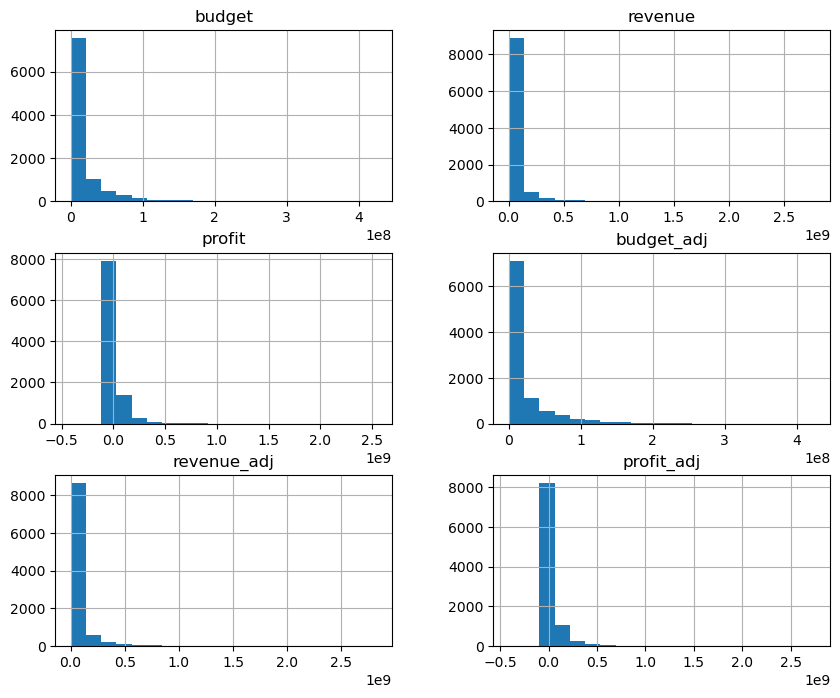

In [15]:
"""
We look at the distribution of the budget,
revenue, profit, budget_adj, revenue_adj, profit_adj
"""

adjusted_col = df[['budget', 'revenue','profit','budget_adj','revenue_adj', 'profit_adj']]
adjusted_col.hist(bins = 20, figsize = (10,8));


The correlation coefficient is [[1.         0.73120354]
 [0.73120354 1.        ]]


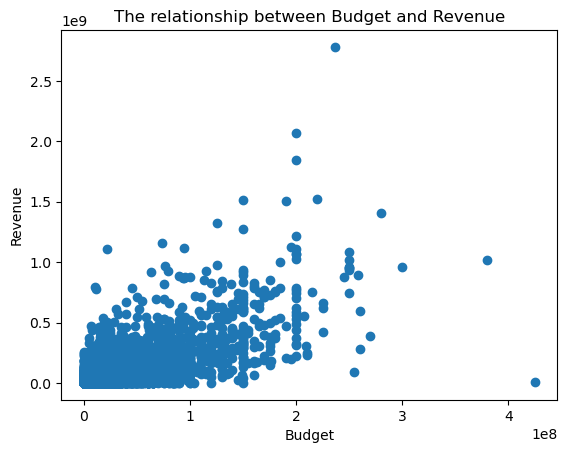

In [16]:
'''
Checking columns and their adjusted to make 
sure they have the similar relationships
'''
def plot_scatter(col1: pd.Series, col2: pd.Series, 
                 label1: str, label2: str, title: str = ""):
    plt.scatter( col1, col2)
    plt.title(title)
    plt.ylabel(label2)
    plt.xlabel(label1)
    correlation = np.corrcoef(np.array(col1.values), np.array(col2.values))
    print('The correlation coefficient is {}'.format(correlation))
plot_scatter(adjusted_col.budget, adjusted_col.revenue, "Budget","Revenue", "The relationship between Budget and Revenue")

The correlation coefficient is [[1.         0.64085173]
 [0.64085173 1.        ]]


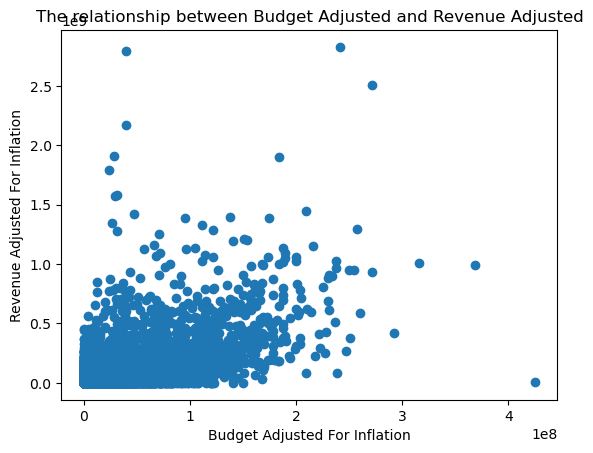

In [17]:
plot_scatter(adjusted_col.budget_adj, adjusted_col.revenue_adj, "Budget Adjusted For Inflation","Revenue Adjusted For Inflation", "The relationship between Budget Adjusted and Revenue Adjusted")

The correlation coefficient is [[1.         0.97807564]
 [0.97807564 1.        ]]


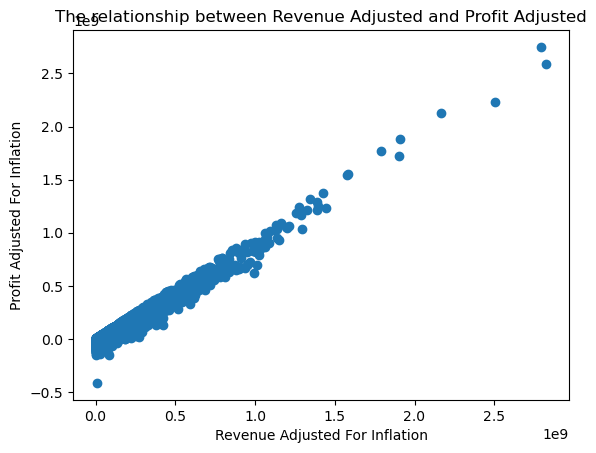

In [18]:
plot_scatter(adjusted_col.revenue_adj, adjusted_col.profit_adj, "Revenue Adjusted For Inflation","Profit Adjusted For Inflation", "The relationship between Revenue Adjusted and Profit Adjusted")

The correlation coefficient is [[1.        0.9762605]
 [0.9762605 1.       ]]


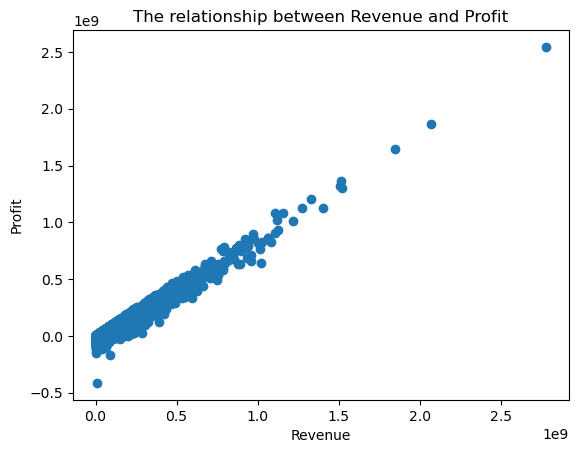

In [19]:
plot_scatter(adjusted_col.revenue, adjusted_col.profit, "Revenue","Profit", "The relationship between Revenue and Profit")

The correlation coefficient is [[1.         0.46693533]
 [0.46693533 1.        ]]


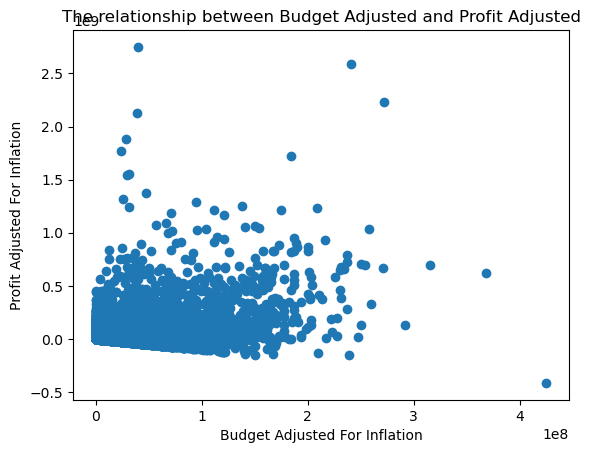

In [20]:
plot_scatter(adjusted_col.budget_adj, adjusted_col.profit_adj, "Budget Adjusted For Inflation","Profit Adjusted For Inflation", "The relationship between Budget Adjusted and Profit Adjusted")

The correlation coefficient is [[1.         0.56608962]
 [0.56608962 1.        ]]


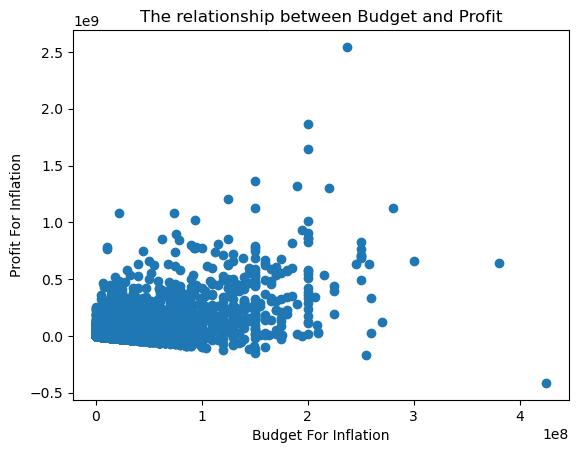

In [21]:
plot_scatter(adjusted_col.budget, adjusted_col.profit, "Budget For Inflation","Profit For Inflation", "The relationship between Budget and Profit")

In [22]:
'''
From the scatter plots above, the adjusted values seems to be more sporadic 
than the unadjusted columns, however, their correlation coefficients have the 
same signs and thier difference are not too significant. Thus, we will be dropping the unadjusted columns 
as this will not affect our analysis and their results will be similar to using the adjusted columns
'''
#Dropping budget, revenue and profit from the main data set
df.drop(columns= ['budget', 'revenue','profit'], inplace= True)

df.head()

,id,popularity,cast,director,runtime,genres,production_companies,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit_adj
0,135397,32.985763,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,5562,6.5,2015,1.379999e+08,1.392446e+09,1.254446e+09
1,76341,28.419936,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,George Miller,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,6185,7.1,2015,1.379999e+08,3.481613e+08,2.101614e+08
2,262500,13.112507,Shailene Woodley|Theo James|Kate Winslet|Ansel...,Robert Schwentke,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,2480,6.3,2015,1.012000e+08,2.716190e+08,1.704191e+08
3,140607,11.173104,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,J.J. Abrams,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,5292,7.5,2015,1.839999e+08,1.902723e+09,1.718723e+09
4,168259,9.335014,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,James Wan,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,2947,7.3,2015,1.747999e+08,1.385749e+09,1.210949e+09


<a id= 'eda'></a>
# Exploratory Data Analysis

<a id= 'eda1'></a>
### #1 Which genre is common amongst the most popular movies over the years?

<ul>
    <li><a href='#home'>Home</a></li>
</ul>


In [23]:
'''
The genre column and production_companies columns 
have multiple values seperated by '|',
so the function:

"split_values" will be used to split the values which will return a pandas dataframe
'''

def split_values(df: pd.DataFrame, column: str) -> pd.DataFrame:
    new_df = pd.DataFrame(columns = list(df.columns)) 
    for value, index in zip(df[column], df.index):
        for s in value.split('|'):
            temp_df = df.copy().loc[index:index, :]
            temp_df[column] = temp_df.loc[index: index,:][column].apply(lambda x: s)
            new_df = pd.concat([new_df,temp_df ])
    return new_df

In [24]:
'''
Splitting the genre in the data for easy analysis
'''
df_splitted_genres = split_values(df, 'genres')
df_splitted_genres.head(1)

,id,popularity,cast,director,runtime,genres,production_companies,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit_adj
0,135397,32.985763,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,124,Action,Universal Studios|Amblin Entertainment|Legenda...,5562,6.5,2015,1.379999e+08,1.392446e+09,1.254446e+09


In [25]:
'''
plot_data is a function to plot graphs with labels, title and legends

it takes labels [x, y] as list if any
         title as str
         and df as a dataframe or series,
         col: list columns to plot
'''

def plot_data(df, title: str, col: list = [], labels: list = []):
    plt.style.use('ggplot')
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = 'Ubuntu'
    plt.rcParams['font.monospace'] = 'Ubuntu Mono'
    plt.rcParams['font.size'] = 10
    plt.rcParams['axes.labelsize'] = 10
    plt.rcParams['axes.labelweight'] = 'bold'
    plt.rcParams['axes.titlesize'] = 10
    plt.rcParams['xtick.labelsize'] = 8
    plt.rcParams['ytick.labelsize'] = 8
    plt.rcParams['legend.fontsize'] = 10
    plt.rcParams['figure.titlesize'] = 12
   
    
    fig = plt.figure(figsize=(10,20), dpi=400)
    
    ax2 = plt.subplot(2,2,(1,2))
    ax1 = plt.subplot(2,2,(3,4))
    
    
    ax1.set_title("Bar Graph of "+title, fontname='Ubuntu', fontsize=14,
            fontstyle='italic', fontweight='bold')
    ax2.set_title('Line Graph of '+title, fontname='Ubuntu', fontsize=14,
            fontstyle='italic', fontweight='bold')
    
    # Space plots a bit
    plt.subplots_adjust(hspace=0.25, wspace=0.40)
    if len(labels) == 0:
        ax1.set(xlabel = col[0], ylabel =col[1] )
        ax2.set(xlabel = col[0], ylabel =col[1] )
    else:
        ax1.set(xlabel = labels[0], ylabel =labels[1] )
        ax2.set(xlabel = labels[0], ylabel = labels[1] )
        
    
    if type(df) == pd.Series:    
        ax1.bar(df.index, df.values)  
        ax2.plot(df.index, df.values, marker = 'o', linewidth = 2)
        ax1.legend(labels[1])
        ax2.legend(labels[1])
        
    else:
        #set width for the bars
        width = 0.3
        i = 0
        x_pos = np.arange(df.shape[0]) +1
        for c in df.columns:
            ax2.plot(df.index, df[c], marker = 'o', linewidth = 2, label = c)
            ax1.bar(x_pos+(width*i), df[c], width = width, label = c)
            i += 1
            
        plt.xticks(x_pos + width, df.index)
        ax1.legend(df.columns)
        ax2.legend(df.columns)
            
    # Rotating X-axis labels
    for tick in ax1.get_xticklabels():
        tick.set_rotation(75)
    
    for tick in ax2.get_xticklabels():
        tick.set_rotation(75)
    
    


<a id ='eda1.10'> Fig 1.0</a>

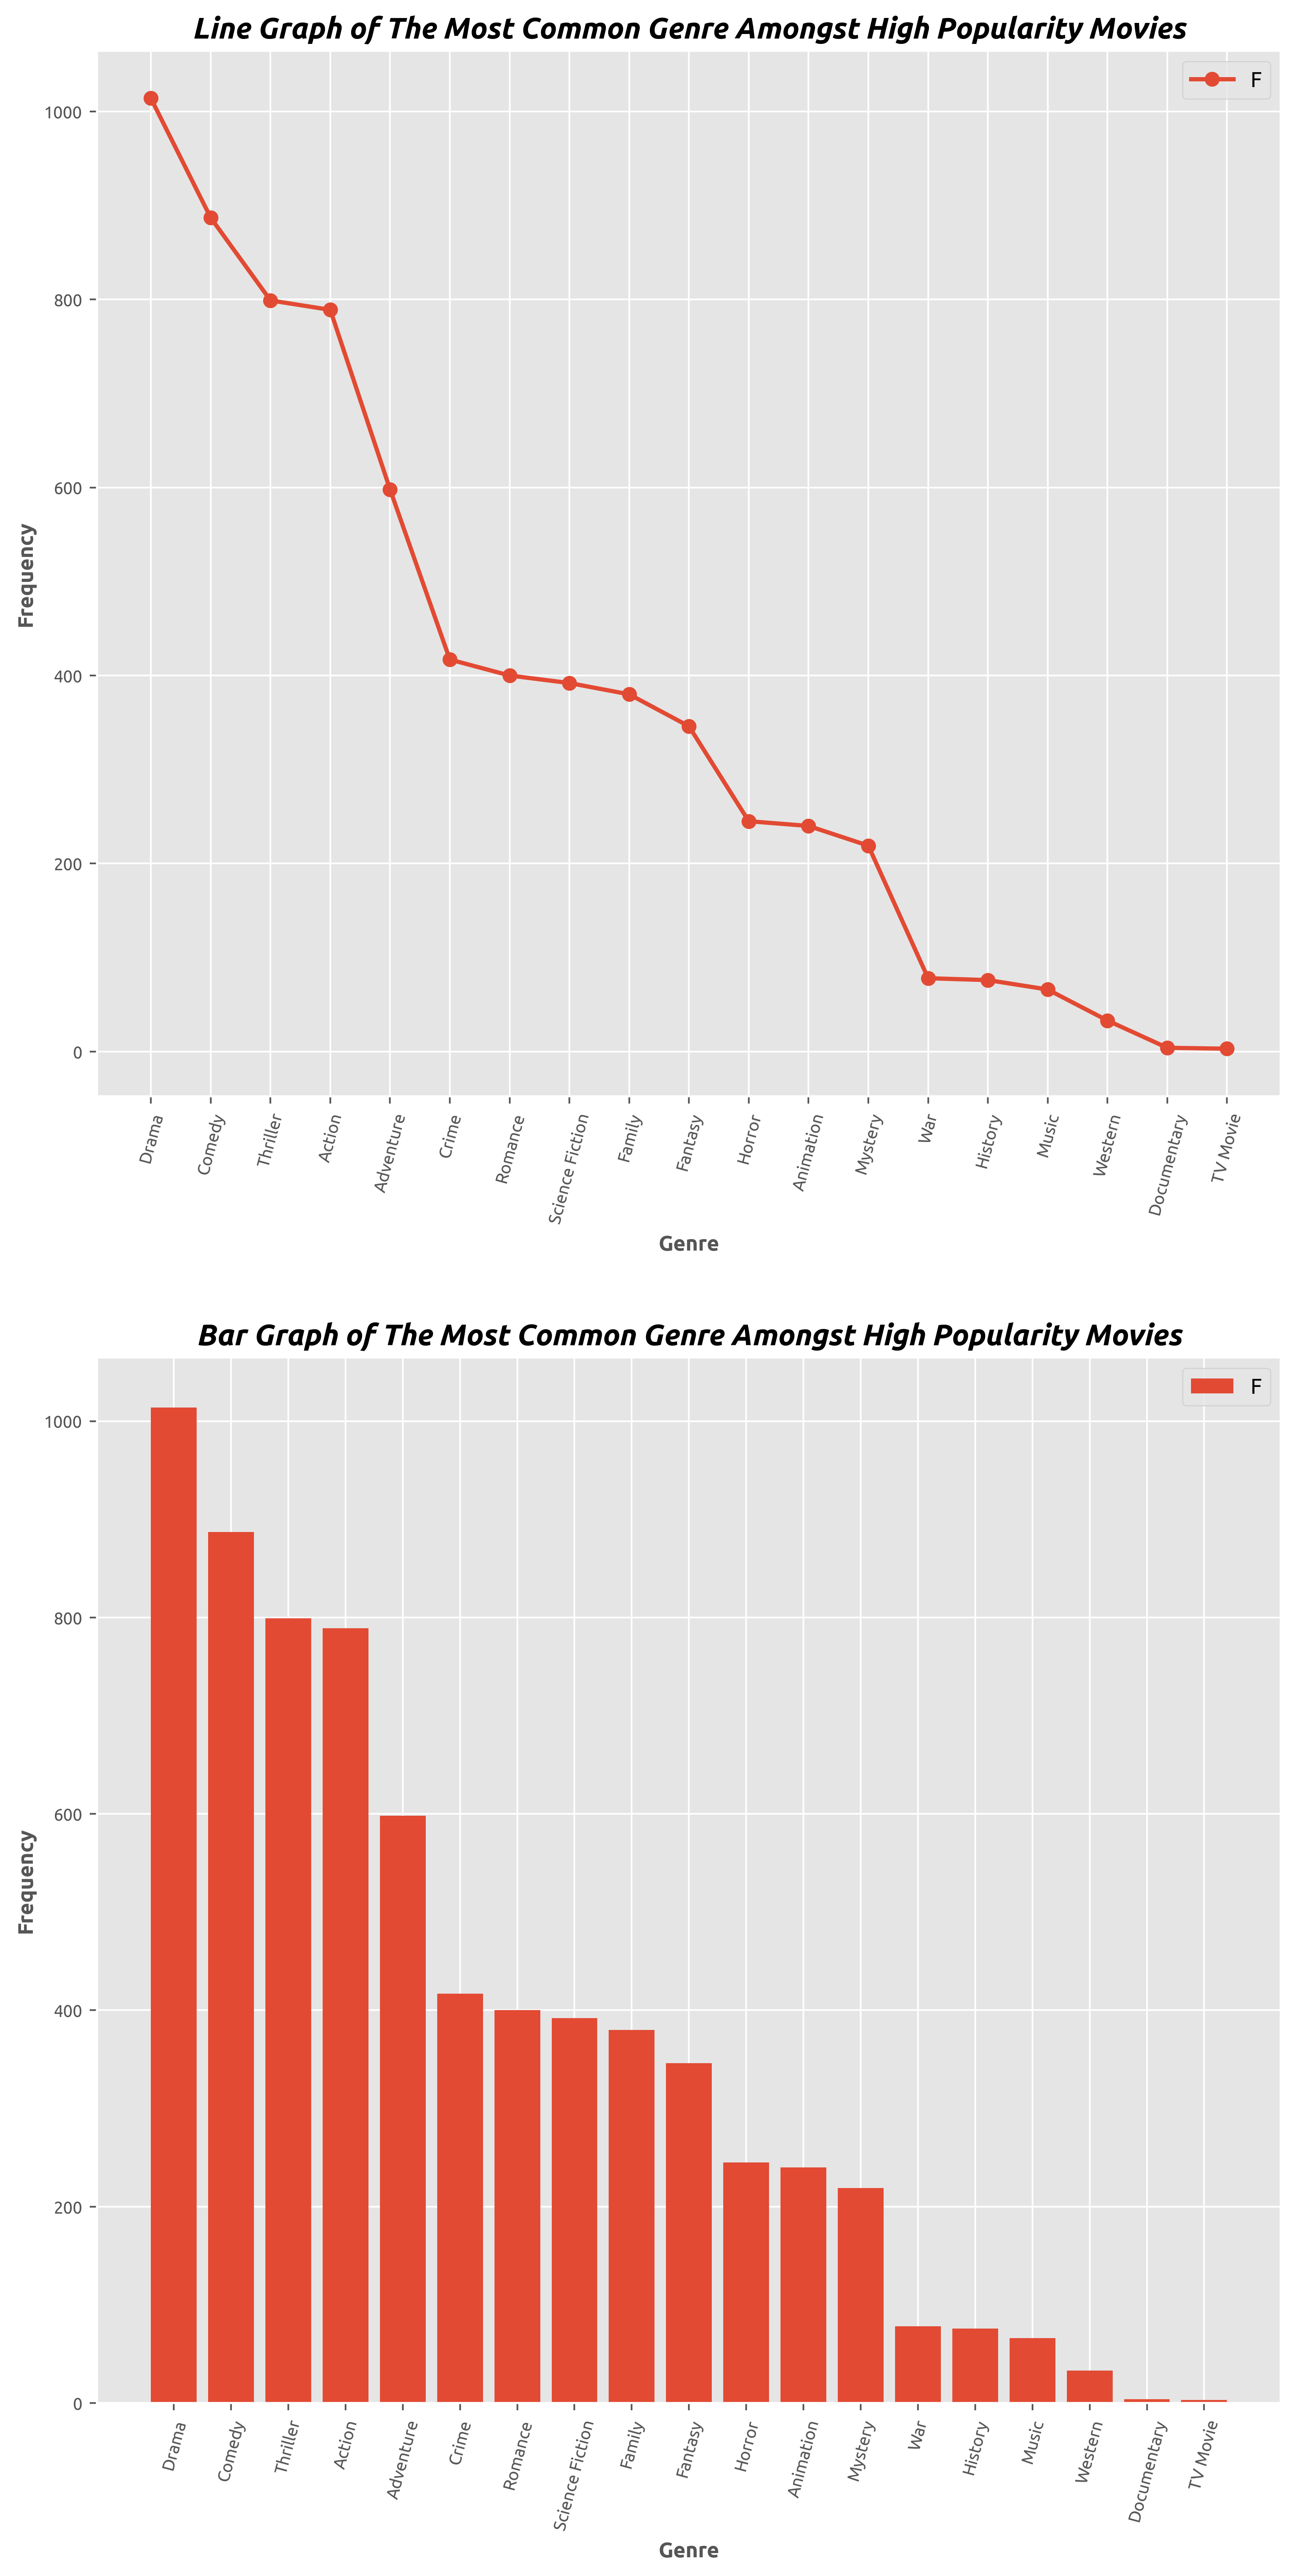

In [26]:
#Grouping data by genres and getting their value counts through out the years
popular_movies = df_splitted_genres.query('popularity >= popularity.mean()')
genres_count = popular_movies.genres.value_counts()

#Plotting the grouped genres with their frequency 
#to visualize and determine the most common genres in high popularity movies over the years
plot_data(df = genres_count, title = 'The Most Common Genre Amongst High Popularity Movies', labels= ['Genre', 'Frequency'], col = [])

- The Chart above shows drama as the most common genre among popular movies over the years with TV movie recording the least

<a id= 'eda2'></a>
### #2 Which genres are associated with high budgets?. Do they come with high revenue and profits?

<ul>
    <li><a href='#home'>Home</a></li>
</ul>

<a id ='eda2.10'> Fig 2.0</a>

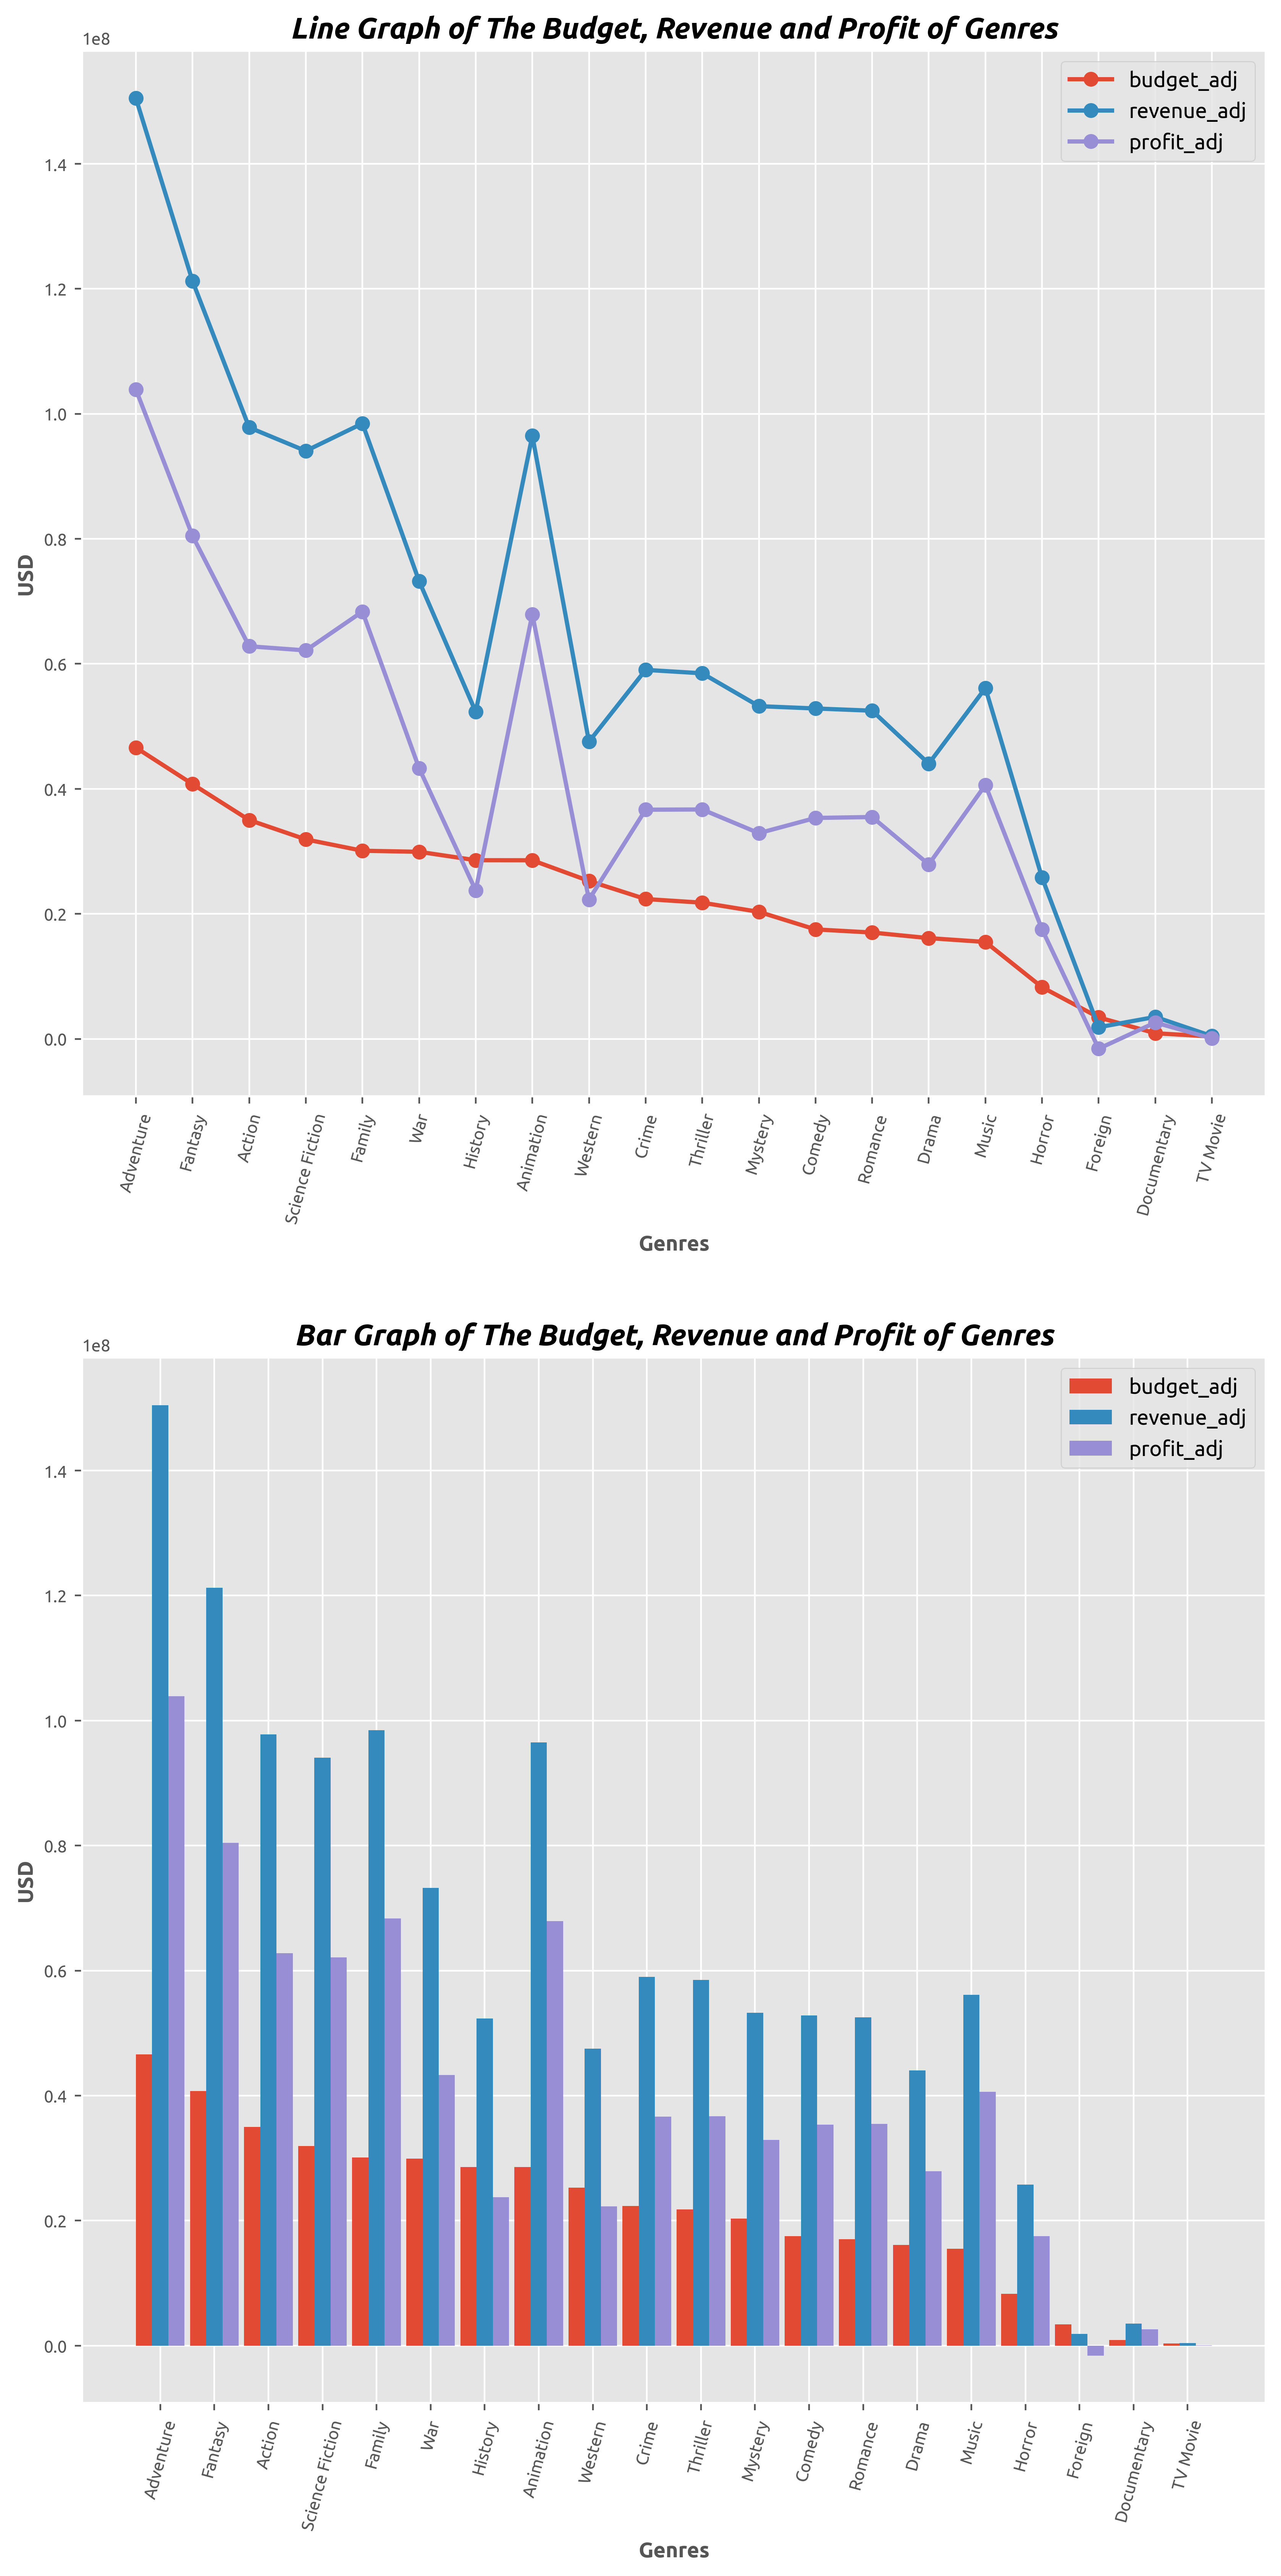

In [27]:
'''
We group the data by the genre and take the average of budget, revenue and profits
'''
grouped_genre = df_splitted_genres.groupby('genres')[['budget_adj','revenue_adj','profit_adj']].mean().sort_values(by='budget_adj', ascending = 0)

#Plotting a graph to show the trends in the budget, revenue and profit by genres over the years
plot_data(df = grouped_genre, title= "The Budget, Revenue and Profit of Genres", labels = ['Genres', 'USD'], col = [])


- The Fig 2.0 above depicts adventure as the  Adventure movies as movies with the highest average budget which also comes with highest revenue and profit and same as the other genres but Foreign movies which has a negative profit with its revenue lesser than the budget

<a id= 'eda3'></a>
### #3 Did any genre record a loss over the years? And by how much?

<ul>
    <li><a href='#home'>Home</a></li>
</ul>

In [28]:
#querying for genres with less than zero profits
loss_genres = grouped_genre.query('profit_adj < 0')
loss_genres['profit_adj']

genres
Foreign   -1.576393e+06
Name: profit_adj, dtype: float64

<a id ='eda3.10'> Fig 3.0</a>

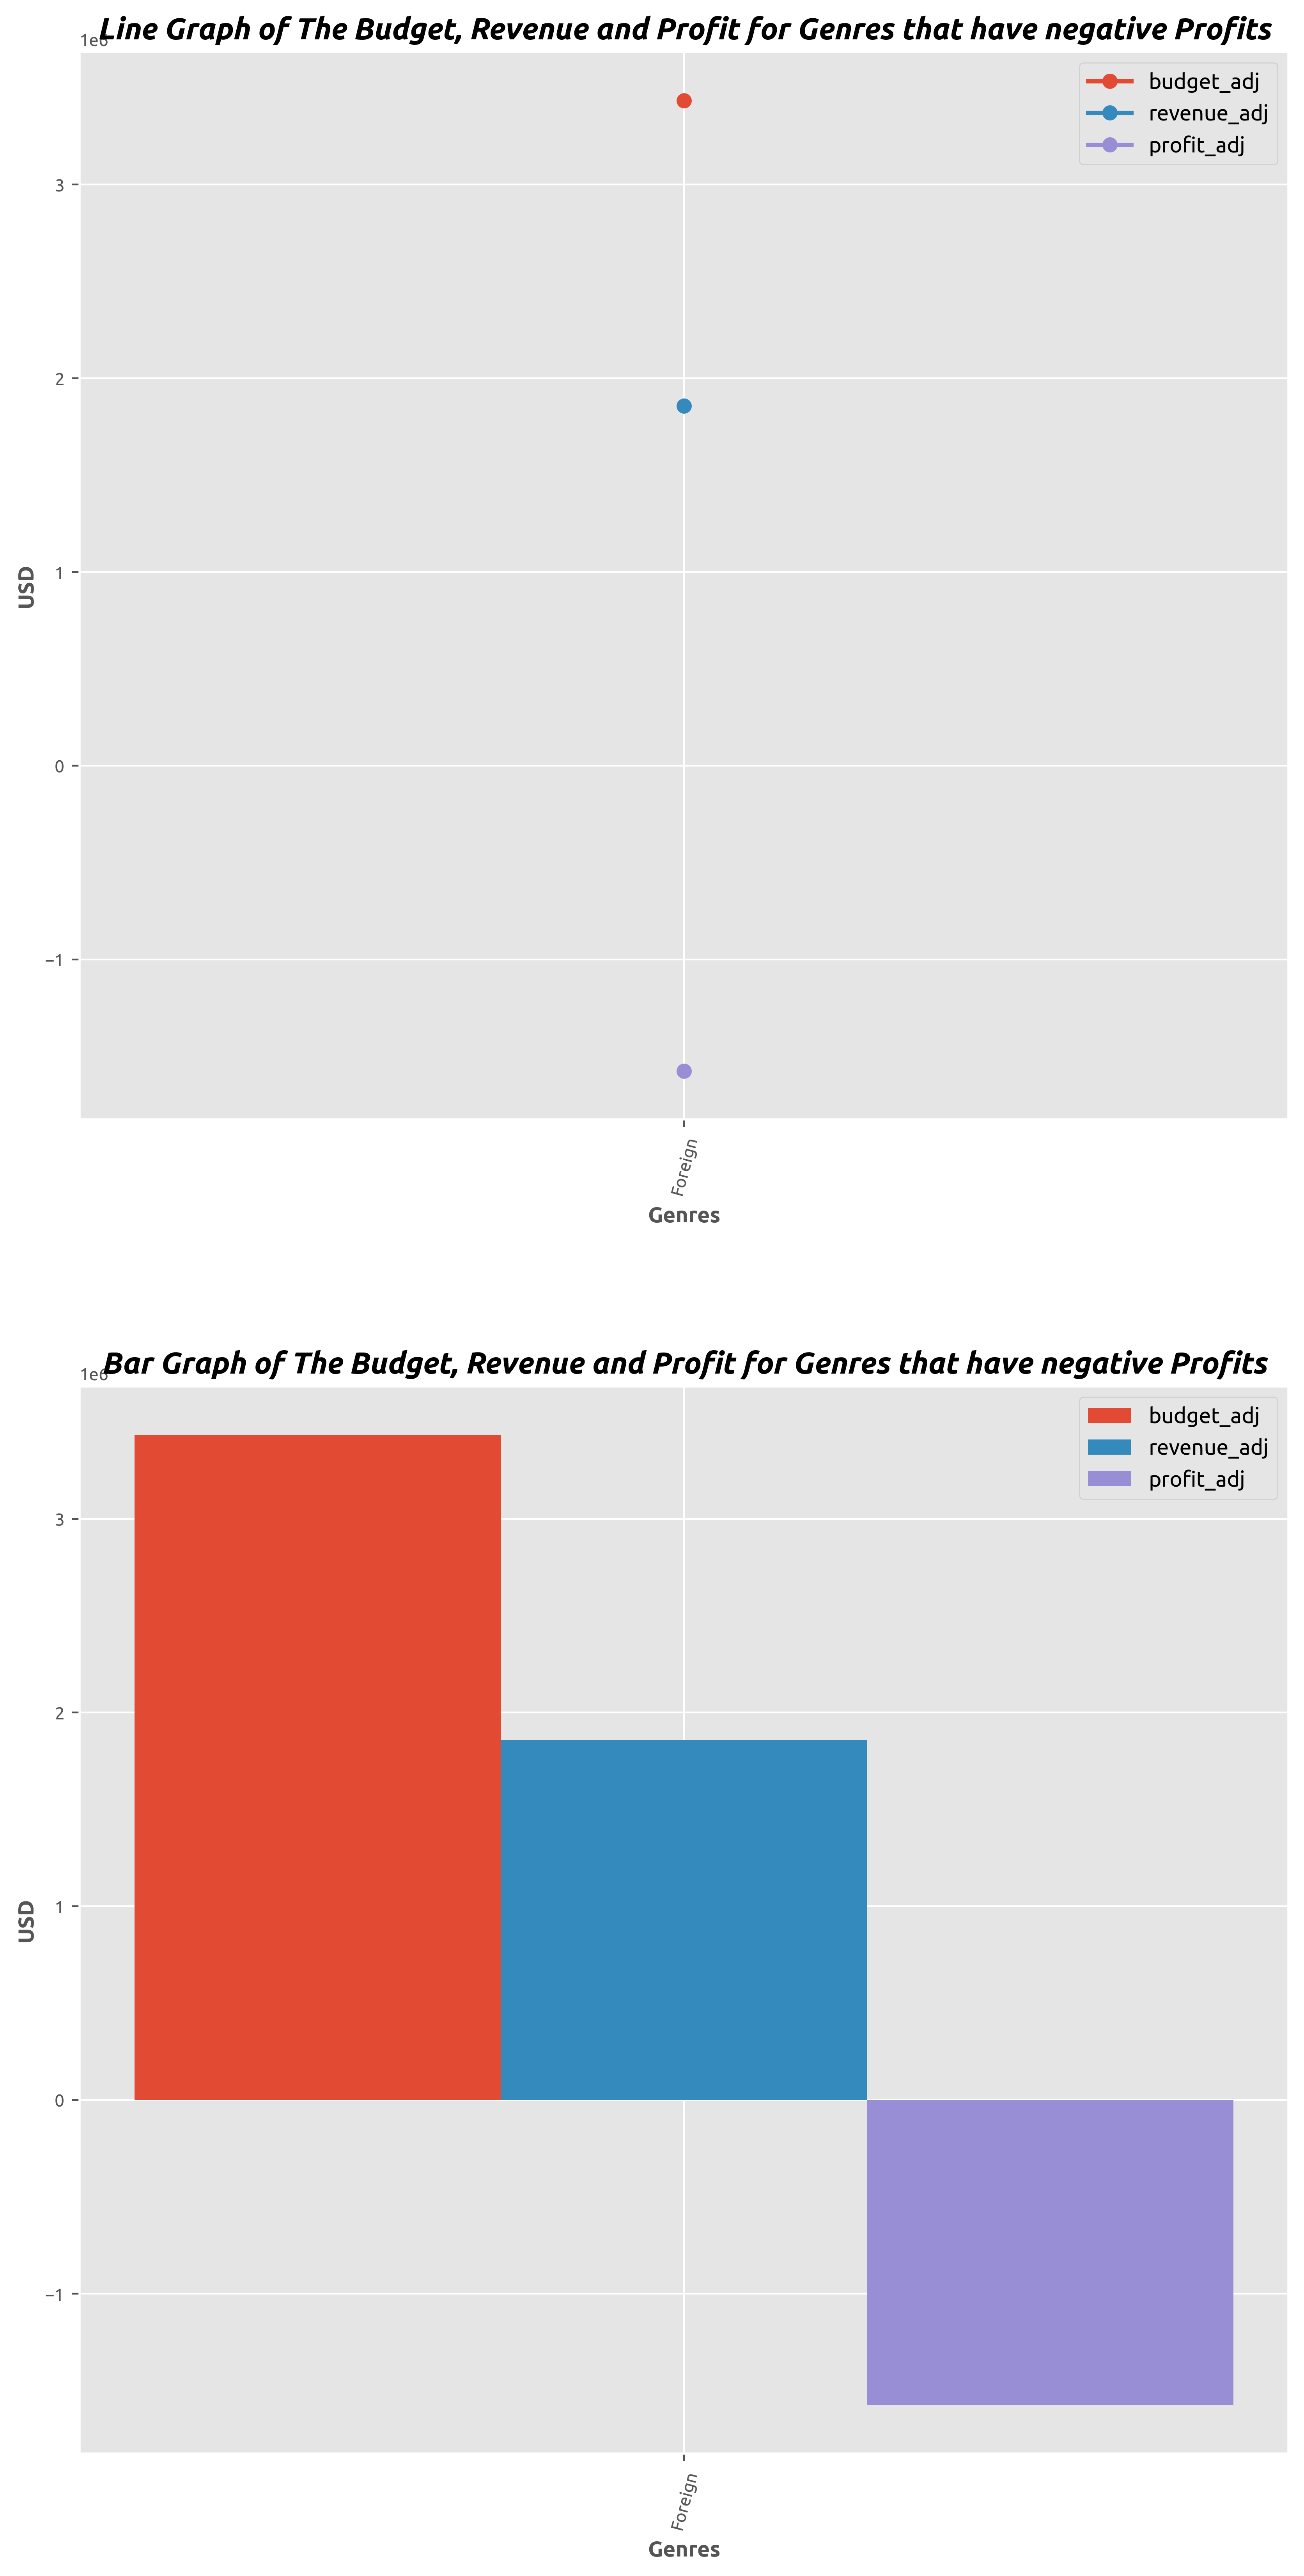

In [29]:
#Visualizing the genres with zero or negative profits
plot_data(df= loss_genres, col= [], title = 'The Budget, Revenue and Profit for Genres that have negative Profits',labels=['Genres', 'USD'])

- Fig 3.0 above confirms our findings in Fig 2.0 showing that more was spent on Foreign movies than earned resulting in the recording of negative profits and it is the only genre with negative profit

<a id= 'eda4'></a>
### #4 The higher the average popularity of a genre, the higher the average profit?

<ul>
    <li><a href='#home'>Home</a></li>
</ul>

<a id ='eda4.10'> Table 1.0</a>

In [30]:
target_df = df_splitted_genres.query('popularity >= popularity.mean()').groupby('genres')[['popularity','profit_adj']].mean()

##Because the value for the profit are large, converting them to log will reduce error
target_df['profit_adj'] = target_df['profit_adj'].apply(lambda x: np.log(x))
#fit model
model = smf.ols(formula= 'profit_adj ~ popularity', data=target_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             profit_adj   R-squared:                       0.714
Model:                            OLS   Adj. R-squared:                  0.696
Method:                 Least Squares   F-statistic:                     39.92
Date:                Sat, 10 Dec 2022   Prob (F-statistic):           1.02e-05
Time:                        12:35:22   Log-Likelihood:                 2.6143
No. Observations:                  18   AIC:                            -1.229
Df Residuals:                      16   BIC:                            0.5521
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     17.0006      0.258     65.811      0.0

/home/johnny/miniconda3/lib/python3.9/site-packages/scipy/stats/stats.py:1541: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


- The OLS table above 0.9428 as the coefficient of the popularity variable, thus the OLS equation is
$$
ln(\hat{y}) =  17.0006 + 0.9428\beta$$
$where \hat{y} = Profit , \beta = Popularity$

So a one unit increased in the average popularity will lead to 0.9428 increase in the profit of popular movies


Text(0.5, 1.0, 'The Scatter Plot of Average Popularity and Profit')

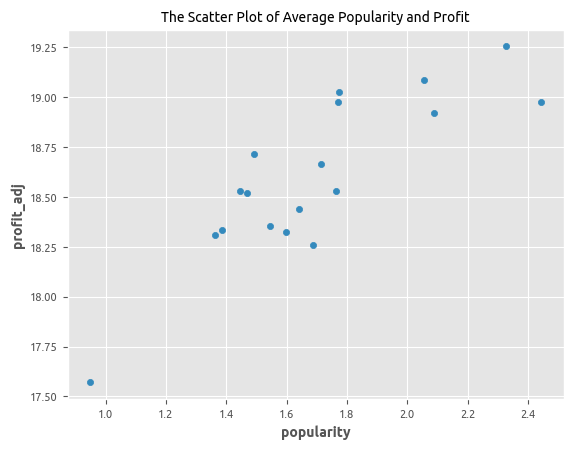

In [31]:
#Plotting the scatter plots of Average Popularity and Profit to visualize and 
#confirm the relationship between them as we have seen from the OLS table
ax = target_df.plot.scatter('popularity','profit_adj')
plt.title('The Scatter Plot of Average Popularity and Profit')

> The scatter plot depicts the positive relationship between the average popularity and profit 

<a id= 'eda5'></a>
### #5 What are the features of popular movies in terms of budget, revenue, and profit year on year?

<ul>
    <li><a href='#home'>Home</a></li>
</ul>

<a id ='eda5.10'> Fig 4.0</a>

[Text(0.5, 1.0, 'The Profit Chart')]

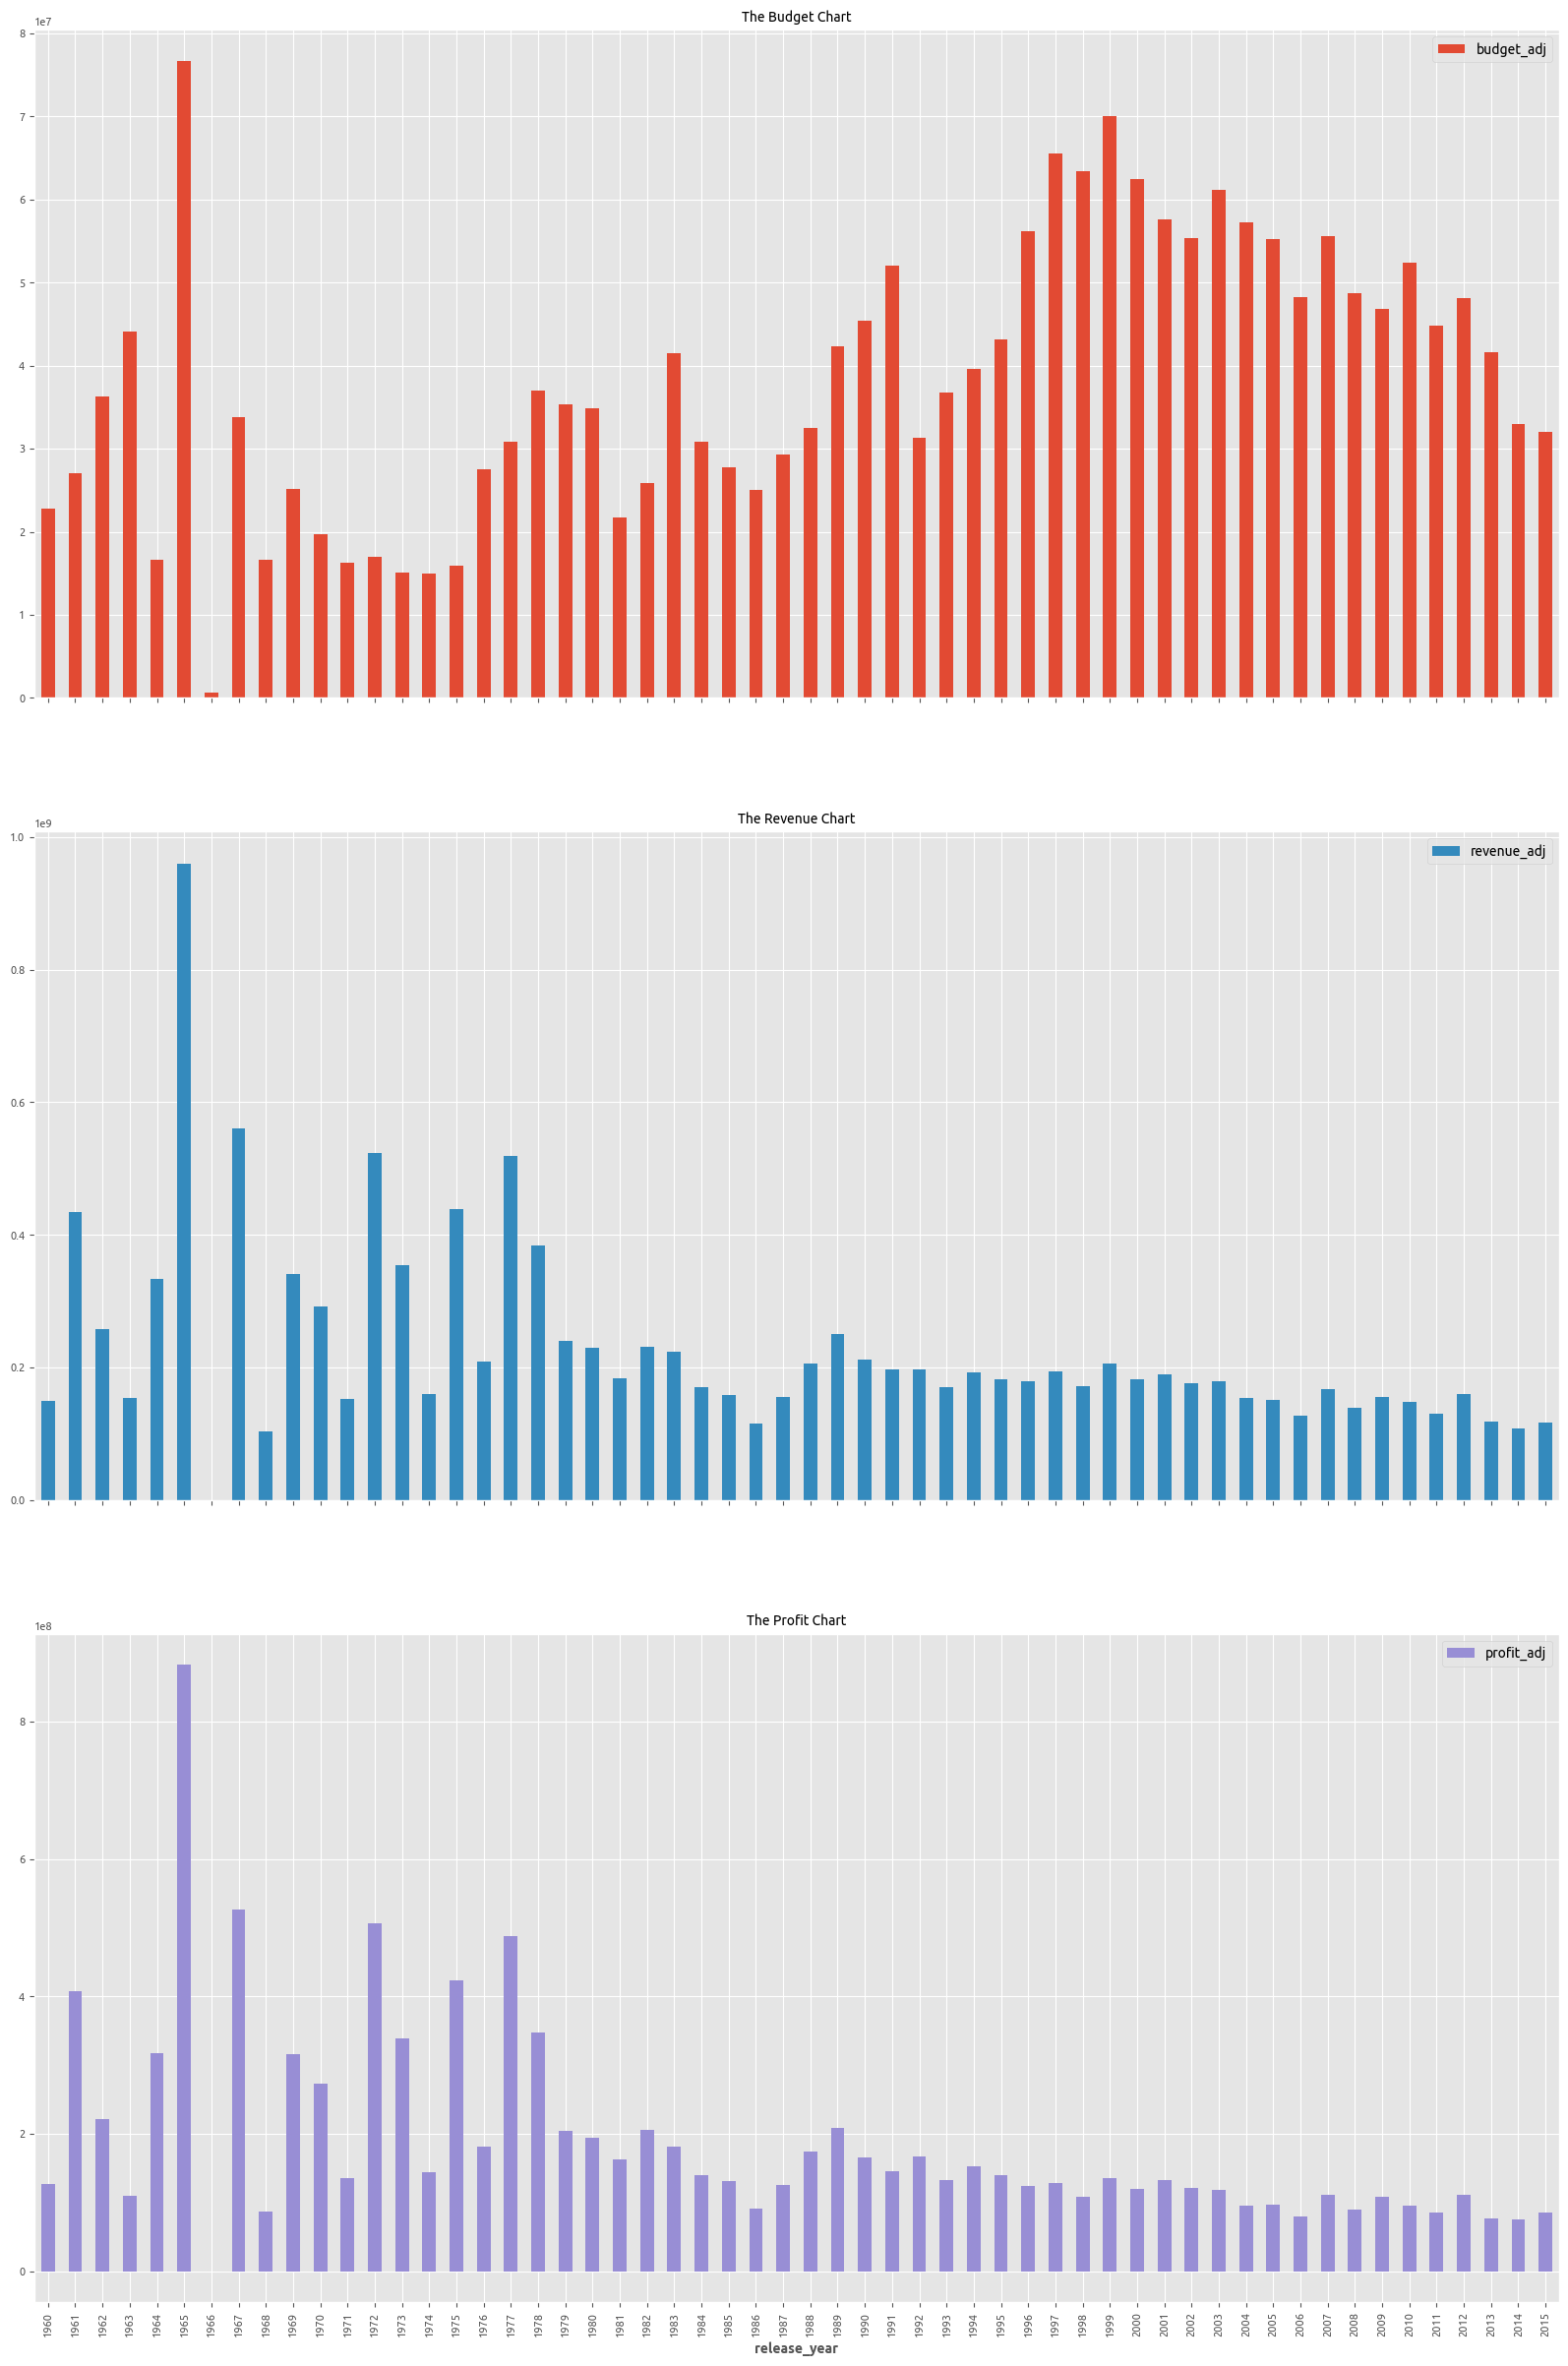

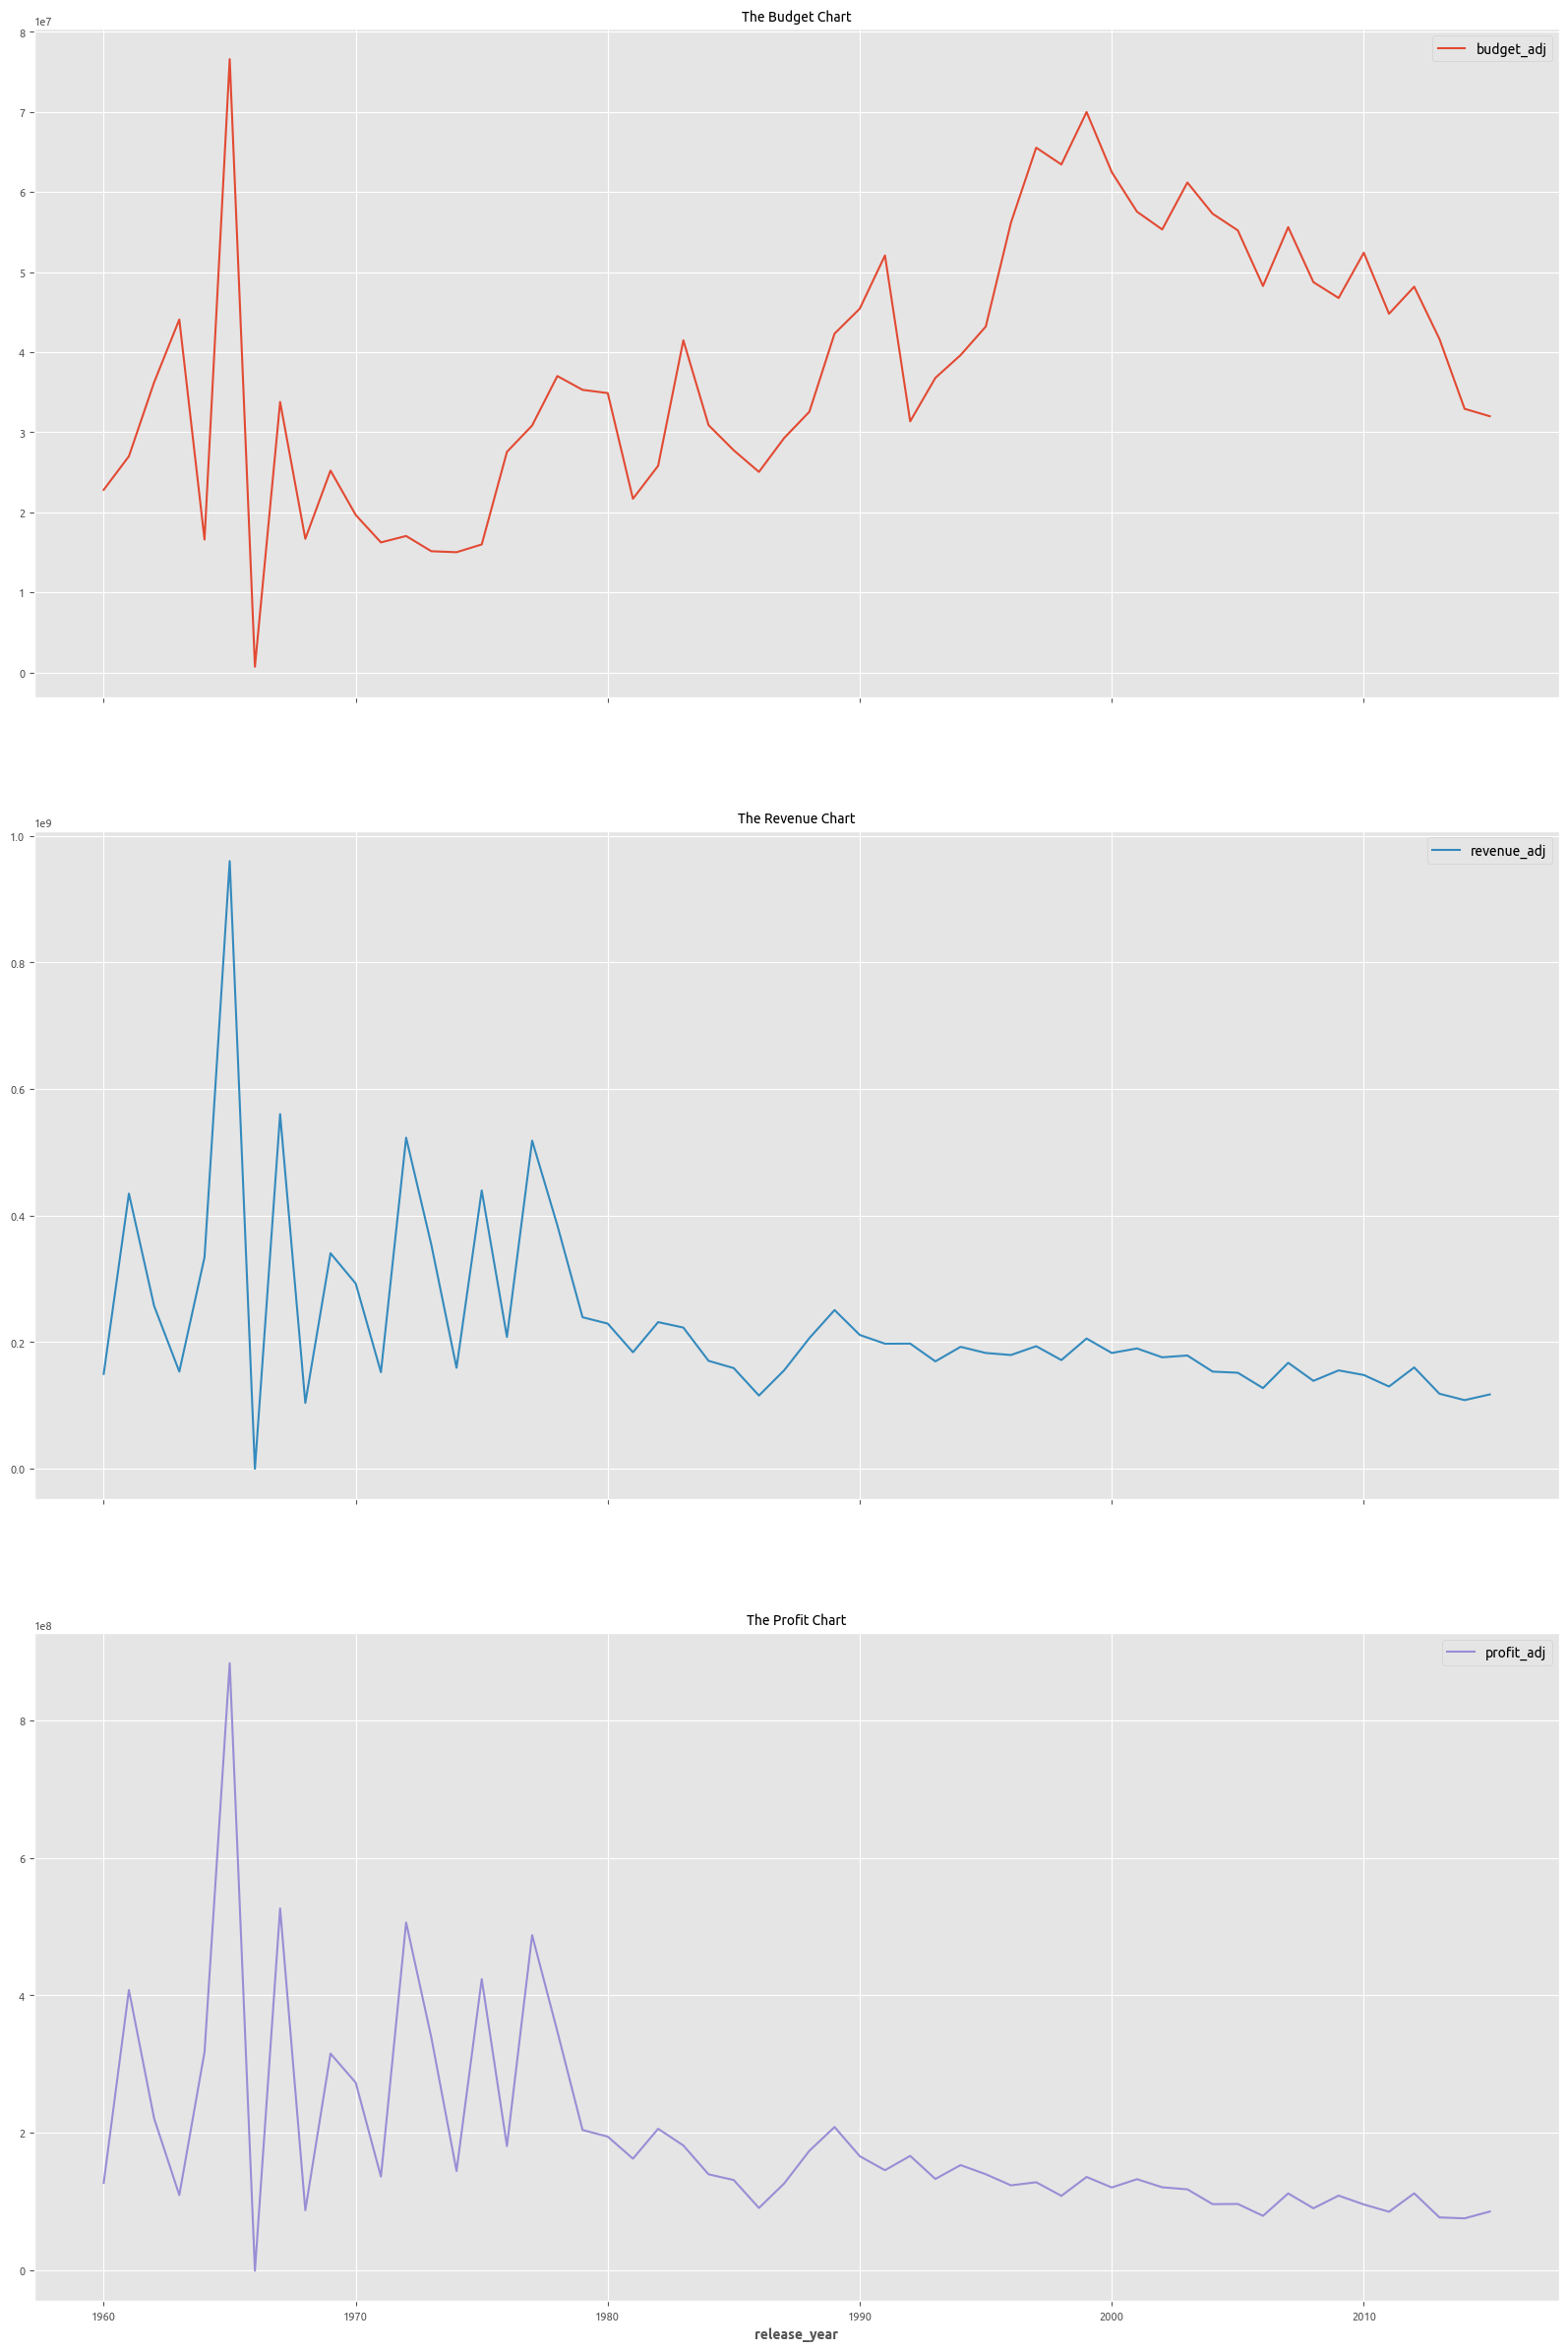

In [32]:
#We query for only popular movies by the average popularity
#and then group them by their release year and calculate for their mean budget, revenue and profit year on year
#Visualizing the trends in the budget, revenue and profit using bar and line graph
df_pop = df.query('popularity >= popularity.mean()').groupby('release_year')[['budget_adj','revenue_adj','profit_adj']].mean()
ax1, ax2, ax3 = df_pop.plot.bar(subplots= True, figsize= (20,30));
ax4,ax5, ax6 = df_pop.plot(subplots = True, figsize = (20,30))

ax1.set(title = "The Budget Chart")
ax2.set(title = "The Revenue Chart")
ax3.set(title = "The Profit Chart")

ax4.set(title = "The Budget Chart")
ax5.set(title = "The Revenue Chart")
ax6.set(title = "The Profit Chart")


> The graph depicts high fluctuations in the budgets throughout the years but with the revenue and profits the level of fluctuations have decreased significantly starting from 1980 

<a id= 'eda6'></a>
### #6 What are the features of popular movies in terms of budget, revenue, and profit in the last five years? 

<ul>
    <li><a href='#home'>Home</a></li>
</ul>

<a id ='eda6.10'> Fig 5.0</a>

[Text(0.5, 1.0, 'The Average Profit Chart of movies in the last five years')]

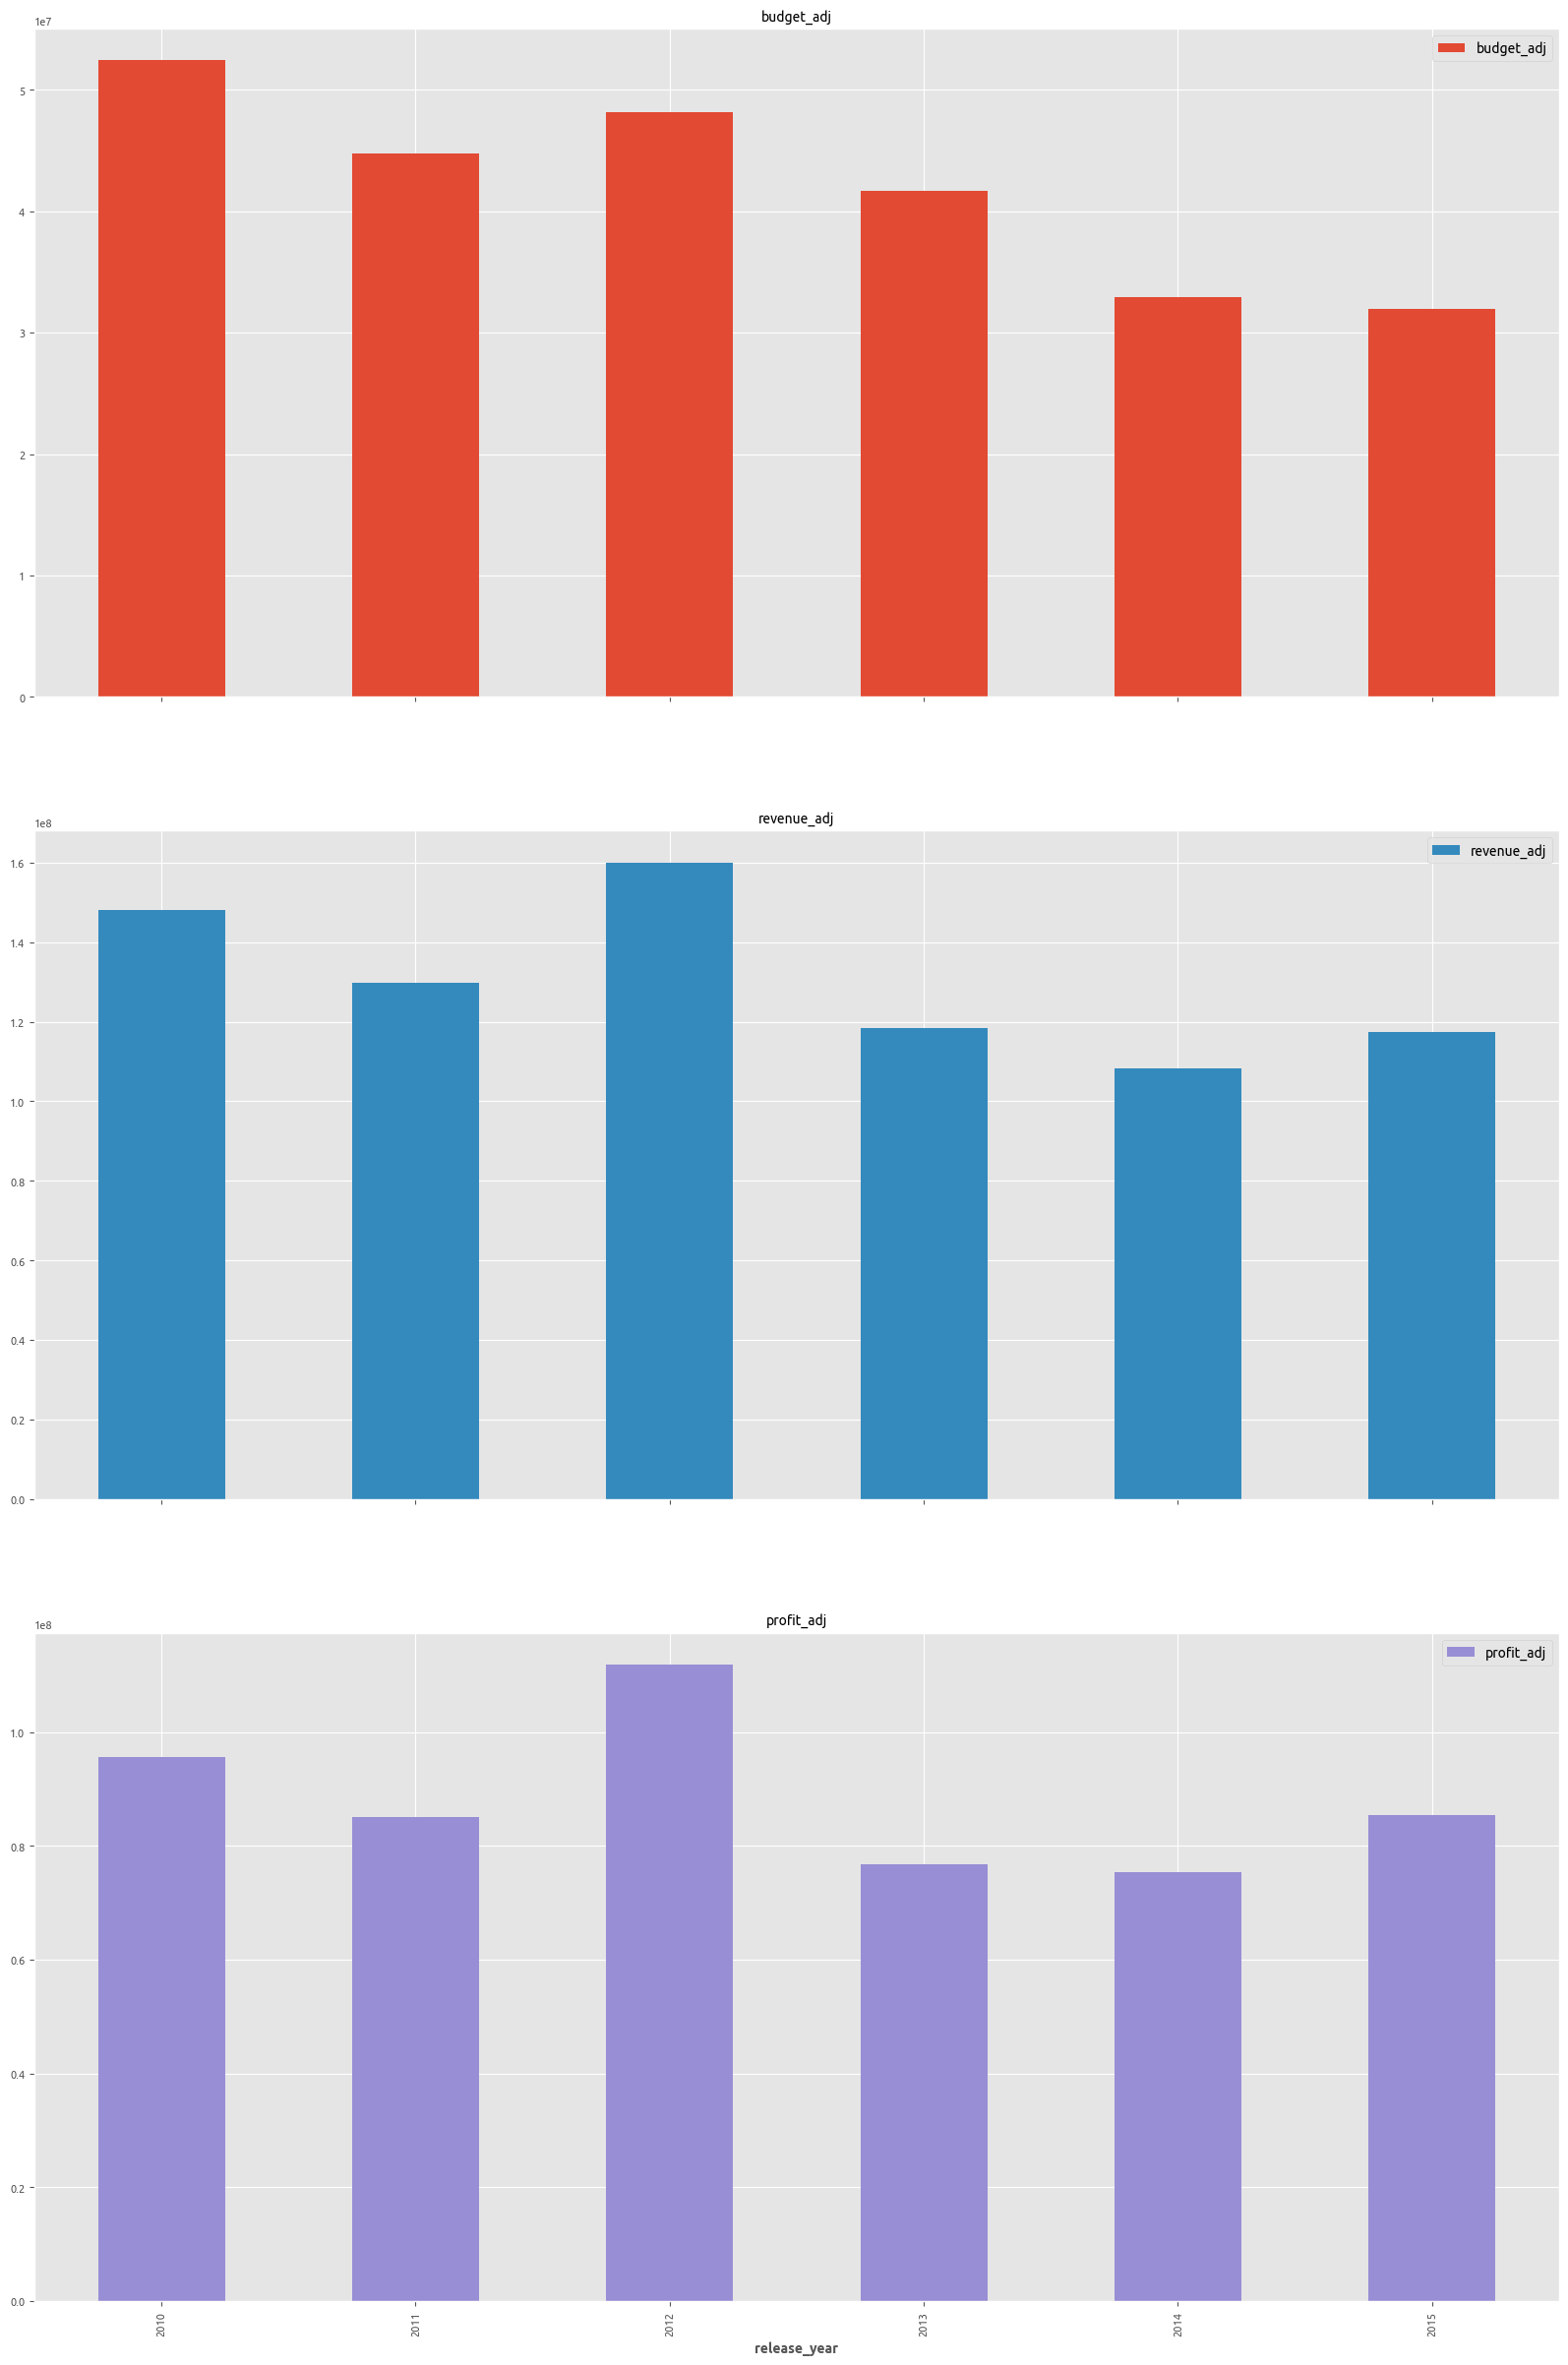

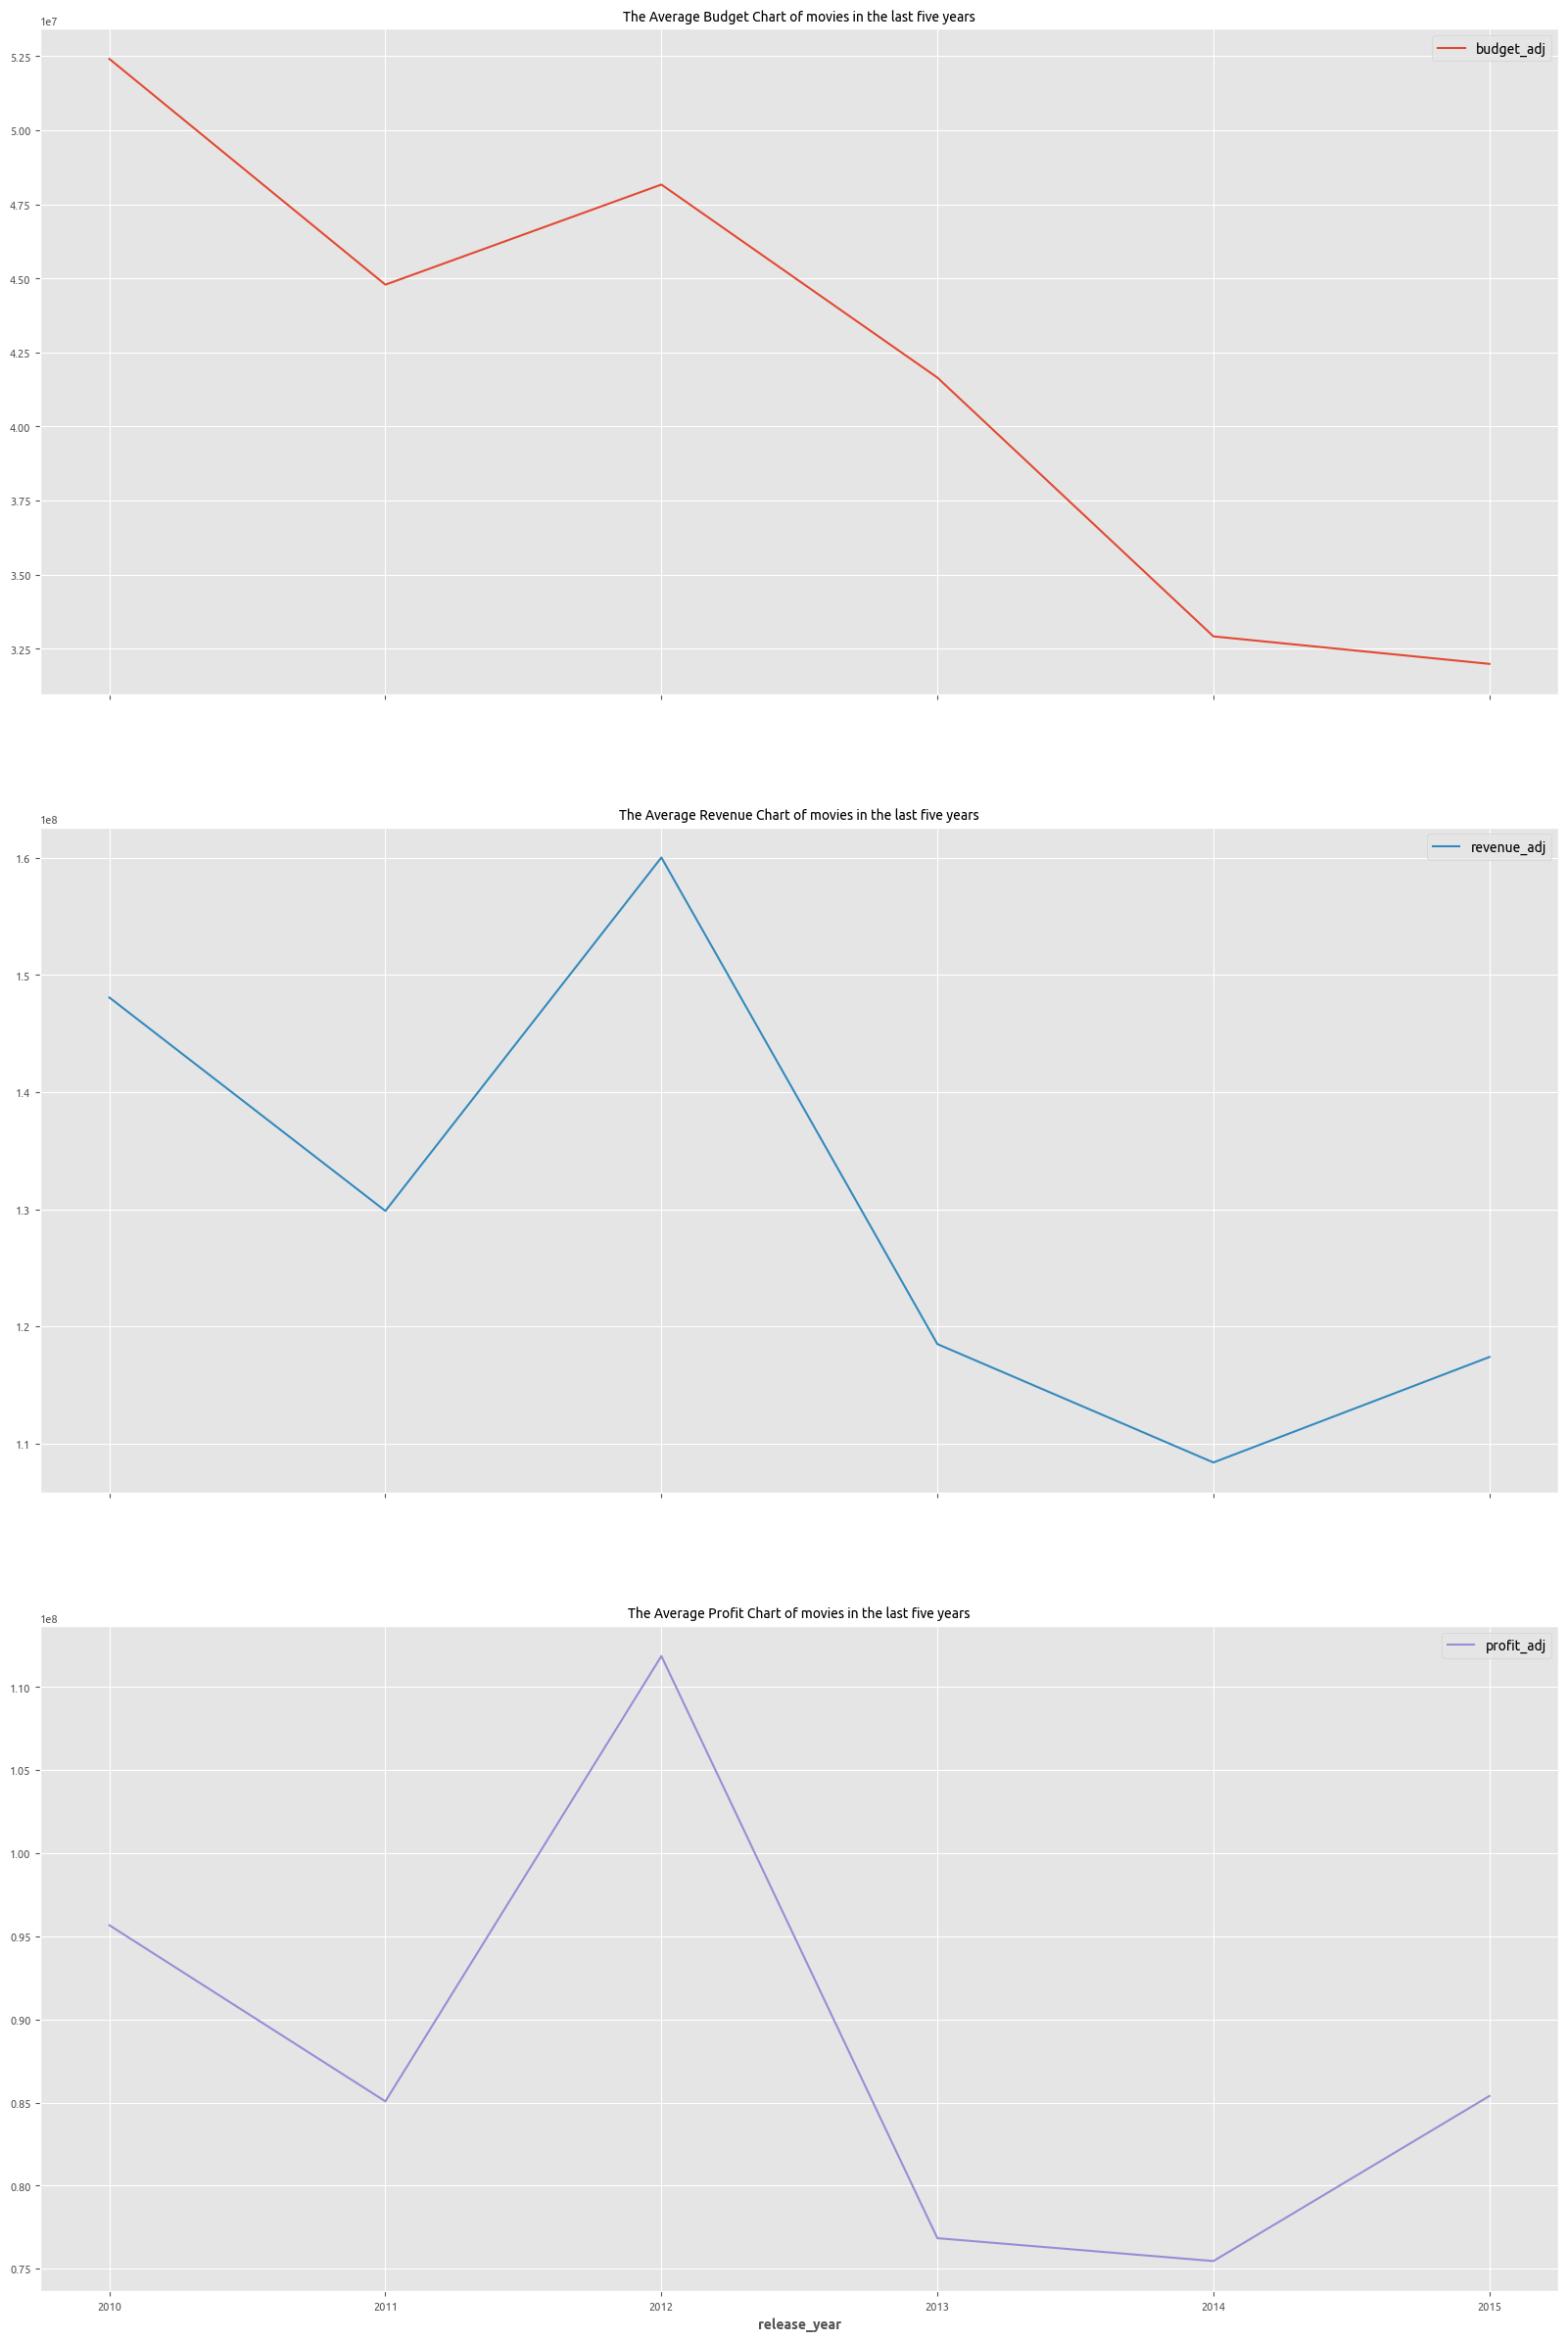

In [33]:
#Querying for the popular movies and
#Grouping them by year and selecting the mean budget, revenue and profit for the last five years 
last_5 = df.query('popularity >= popularity.mean()').groupby('release_year')[['budget_adj','revenue_adj','profit_adj']].mean().loc['2010':'2015',:]

#Visualizing the trends
ax,ax1, ax2 =last_5.plot.bar(subplots= True, figsize = (20,30));
ax,ax1, ax2 = last_5.plot(subplots = True, figsize = (20,30))
ax.set(title = "The Average Budget Chart of movies in the last five years")
ax1.set(title = "The Average Revenue Chart of movies in the last five years")
ax2.set(title = "The Average Profit Chart of movies in the last five years")


- The chart depicts high fluctuations in the first three years followed by a sharp and then a steady decrease in budgets where as fluctuations through out the last five years in the revenue and profit

In [34]:
#SHowing the basic stats about the last five years
last_5.describe()

,budget_adj,revenue_adj,profit_adj
count,6.000000e+00,6.000000e+00,6.000000e+00
mean,4.198696e+07,1.303684e+08,8.838146e+07
std,8.210235e+06,1.993718e+07,1.360040e+07
min,3.198781e+07,1.083762e+08,7.545943e+07
25%,3.510055e+07,1.176564e+08,7.889284e+07
50%,4.322006e+07,1.241716e+08,8.523047e+07
75%,4.732270e+07,1.435225e+08,9.309904e+07
max,5.240954e+07,1.600337e+08,1.118662e+08


<a id= 'eda7'></a>
### #7 Which production companies are among the top 10 movie producers of popular movies?

<ul>
    <li><a href='#home'>Home</a></li>
</ul>

In [35]:
'''
Splitting values production companies  using the `splitted_values` function
'''

df_splitted_comp = split_values(df, 'production_companies')

df_splitted_comp.head(2)

,id,popularity,cast,director,runtime,genres,production_companies,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit_adj
0,135397,32.985763,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,124,Action|Adventure|Science Fiction|Thriller,Universal Studios,5562,6.5,2015,1.379999e+08,1.392446e+09,1.254446e+09
0,135397,32.985763,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,124,Action|Adventure|Science Fiction|Thriller,Amblin Entertainment,5562,6.5,2015,1.379999e+08,1.392446e+09,1.254446e+09


<a id ='eda7.10'> Fig 6.0</a>

In [36]:
#querying by average the popular movies and selecting the top 10 production companies with the movie highest count
top_10_prod = df_splitted_comp.query('popularity >= popularity.mean()').production_companies.value_counts().sort_values(ascending = False)[:11]
top_10_prod

Warner Bros.                              221
Universal Pictures                        210
Paramount Pictures                        154
Twentieth Century Fox Film Corporation    138
Columbia Pictures                         113
Walt Disney Pictures                      108
New Line Cinema                            96
Relativity Media                           80
Metro-Goldwyn-Mayer (MGM)                  67
Columbia Pictures Corporation              57
Touchstone Pictures                        57
Name: production_companies, dtype: int64

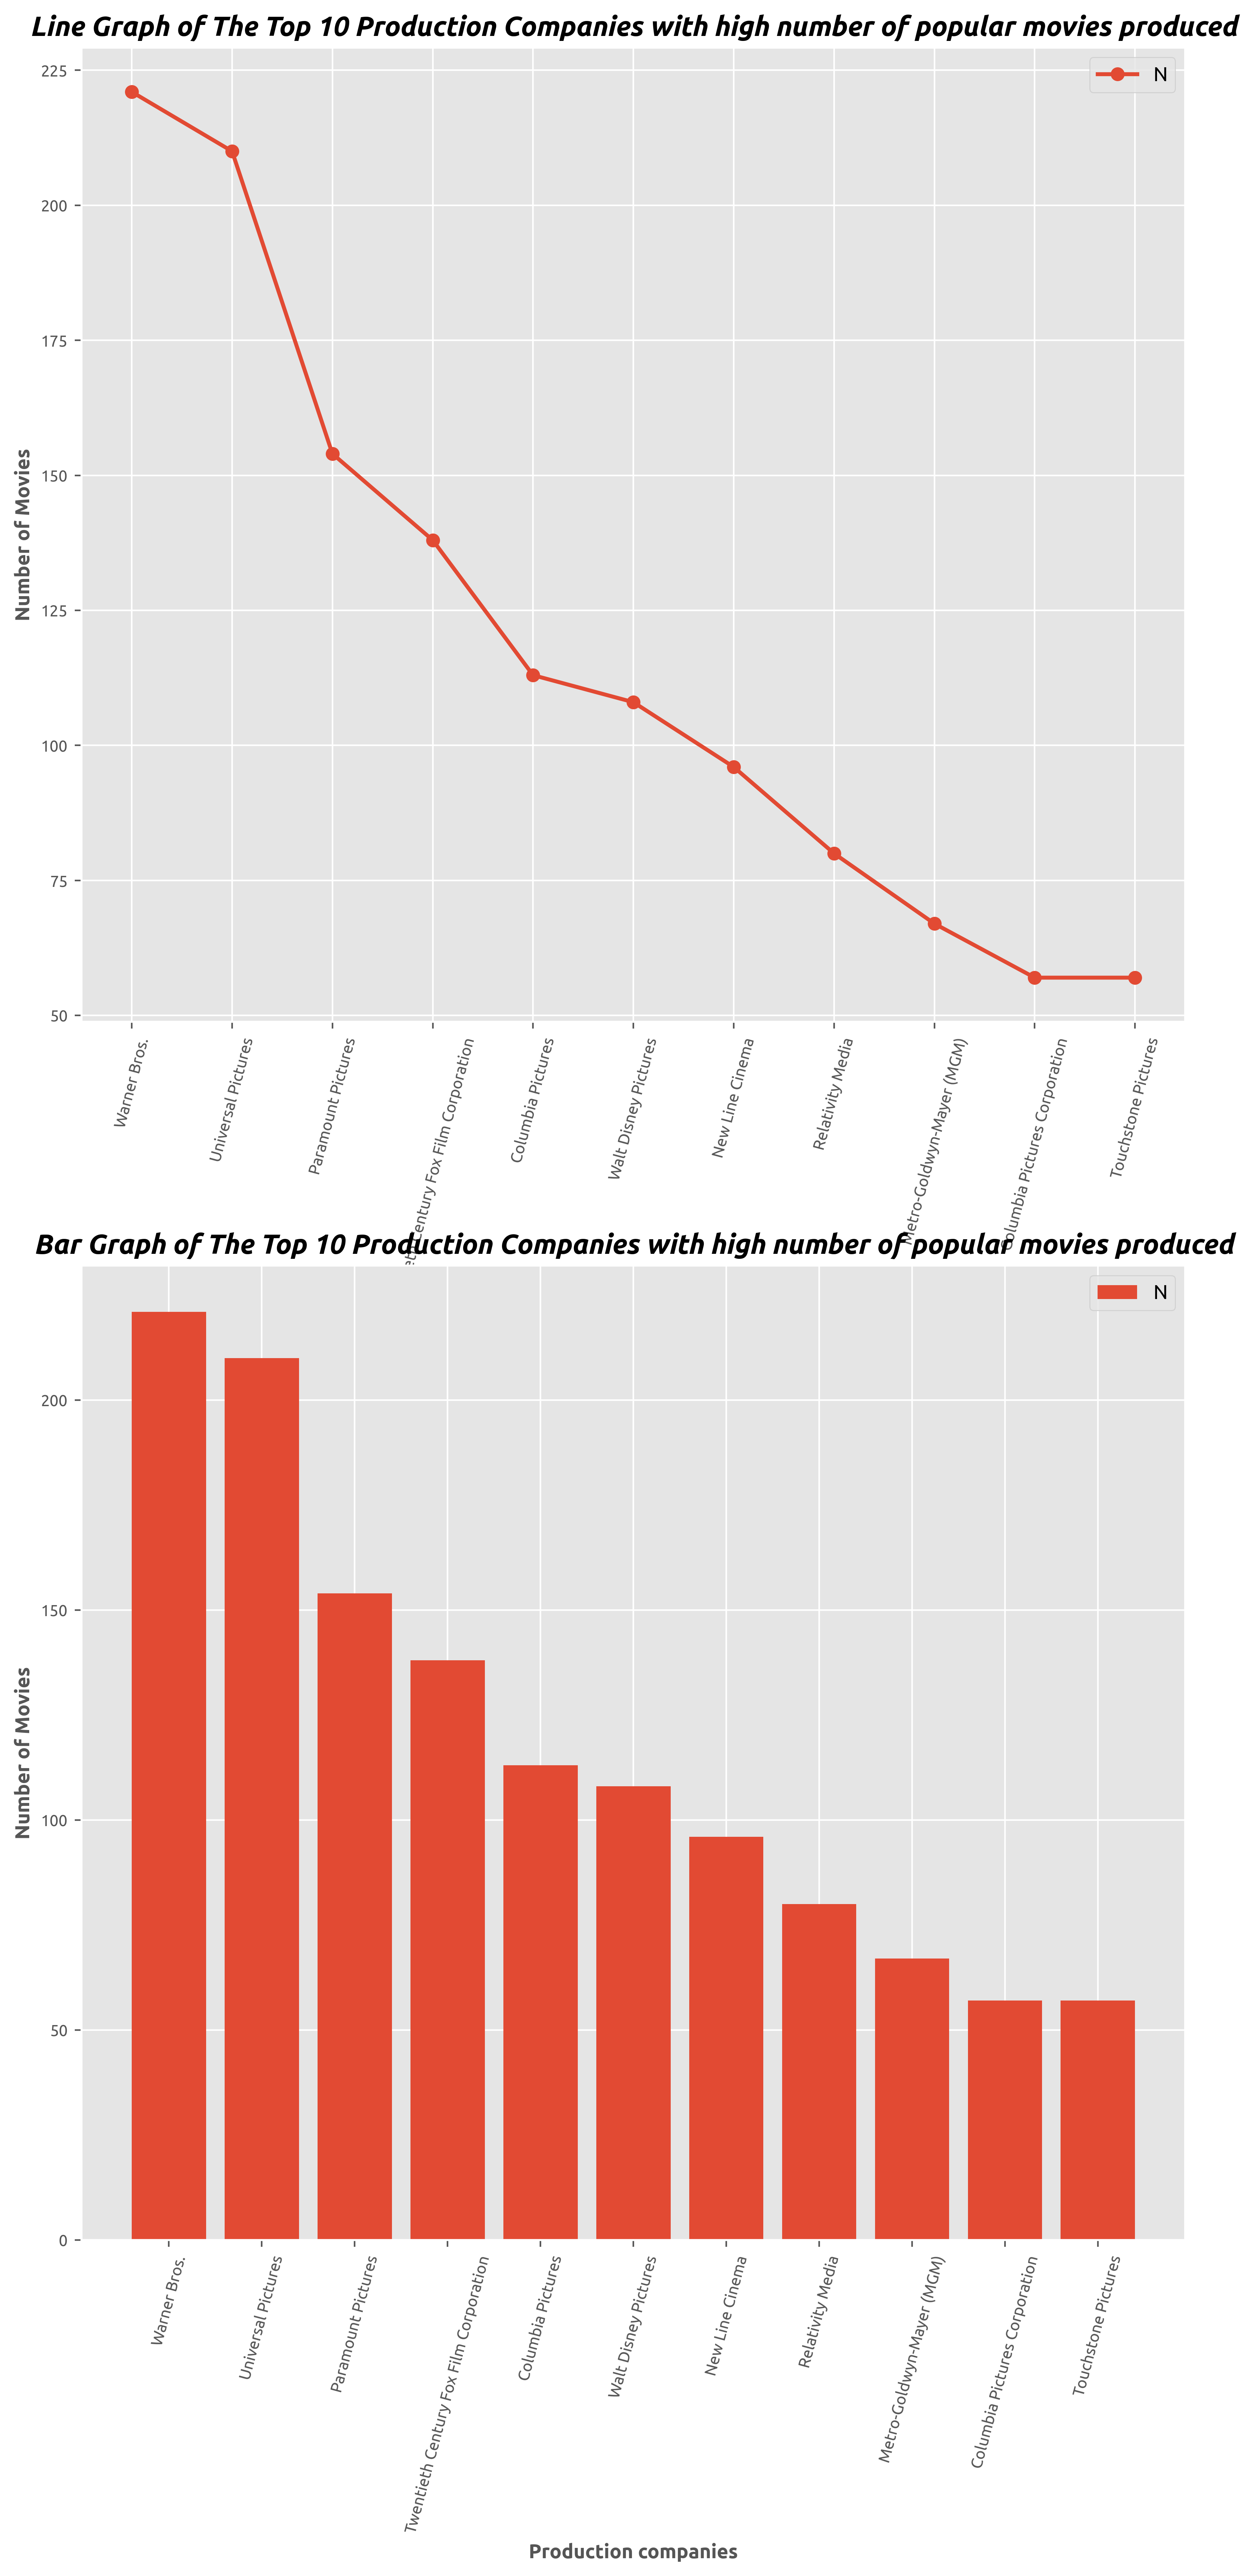

In [37]:
#Visualizing the top 10 production companies with the highest popular  movies 
plot_data(df = top_10_prod, col = [], labels=['Production companies', 'Number of Movies'], title = 'The Top 10 Production Companies with high number of popular movies produced')

- The chart shows Warner Bros as the highest producer of popular movies over the years among the top 10 popular movies producers

<a id= 'eda8'></a>
### #8 Which production companies are the overall top 10 movie producers and how many movies have they produced over the years?

<ul>
    <li><a href='#home'>Home</a></li>
</ul>

<a id ='eda8.10'> Fig 7.0</a>

In [38]:
#Getting the value count for the overall top 10 movie production companies with the highest movies over the years
top_10 = df_splitted_comp.production_companies.value_counts().sort_values(ascending = False)[:11]
top_10

Universal Pictures                        522
Warner Bros.                              509
Paramount Pictures                        431
Twentieth Century Fox Film Corporation    282
Columbia Pictures                         272
New Line Cinema                           219
Metro-Goldwyn-Mayer (MGM)                 218
Walt Disney Pictures                      213
Touchstone Pictures                       178
Columbia Pictures Corporation             160
TriStar Pictures                          147
Name: production_companies, dtype: int64

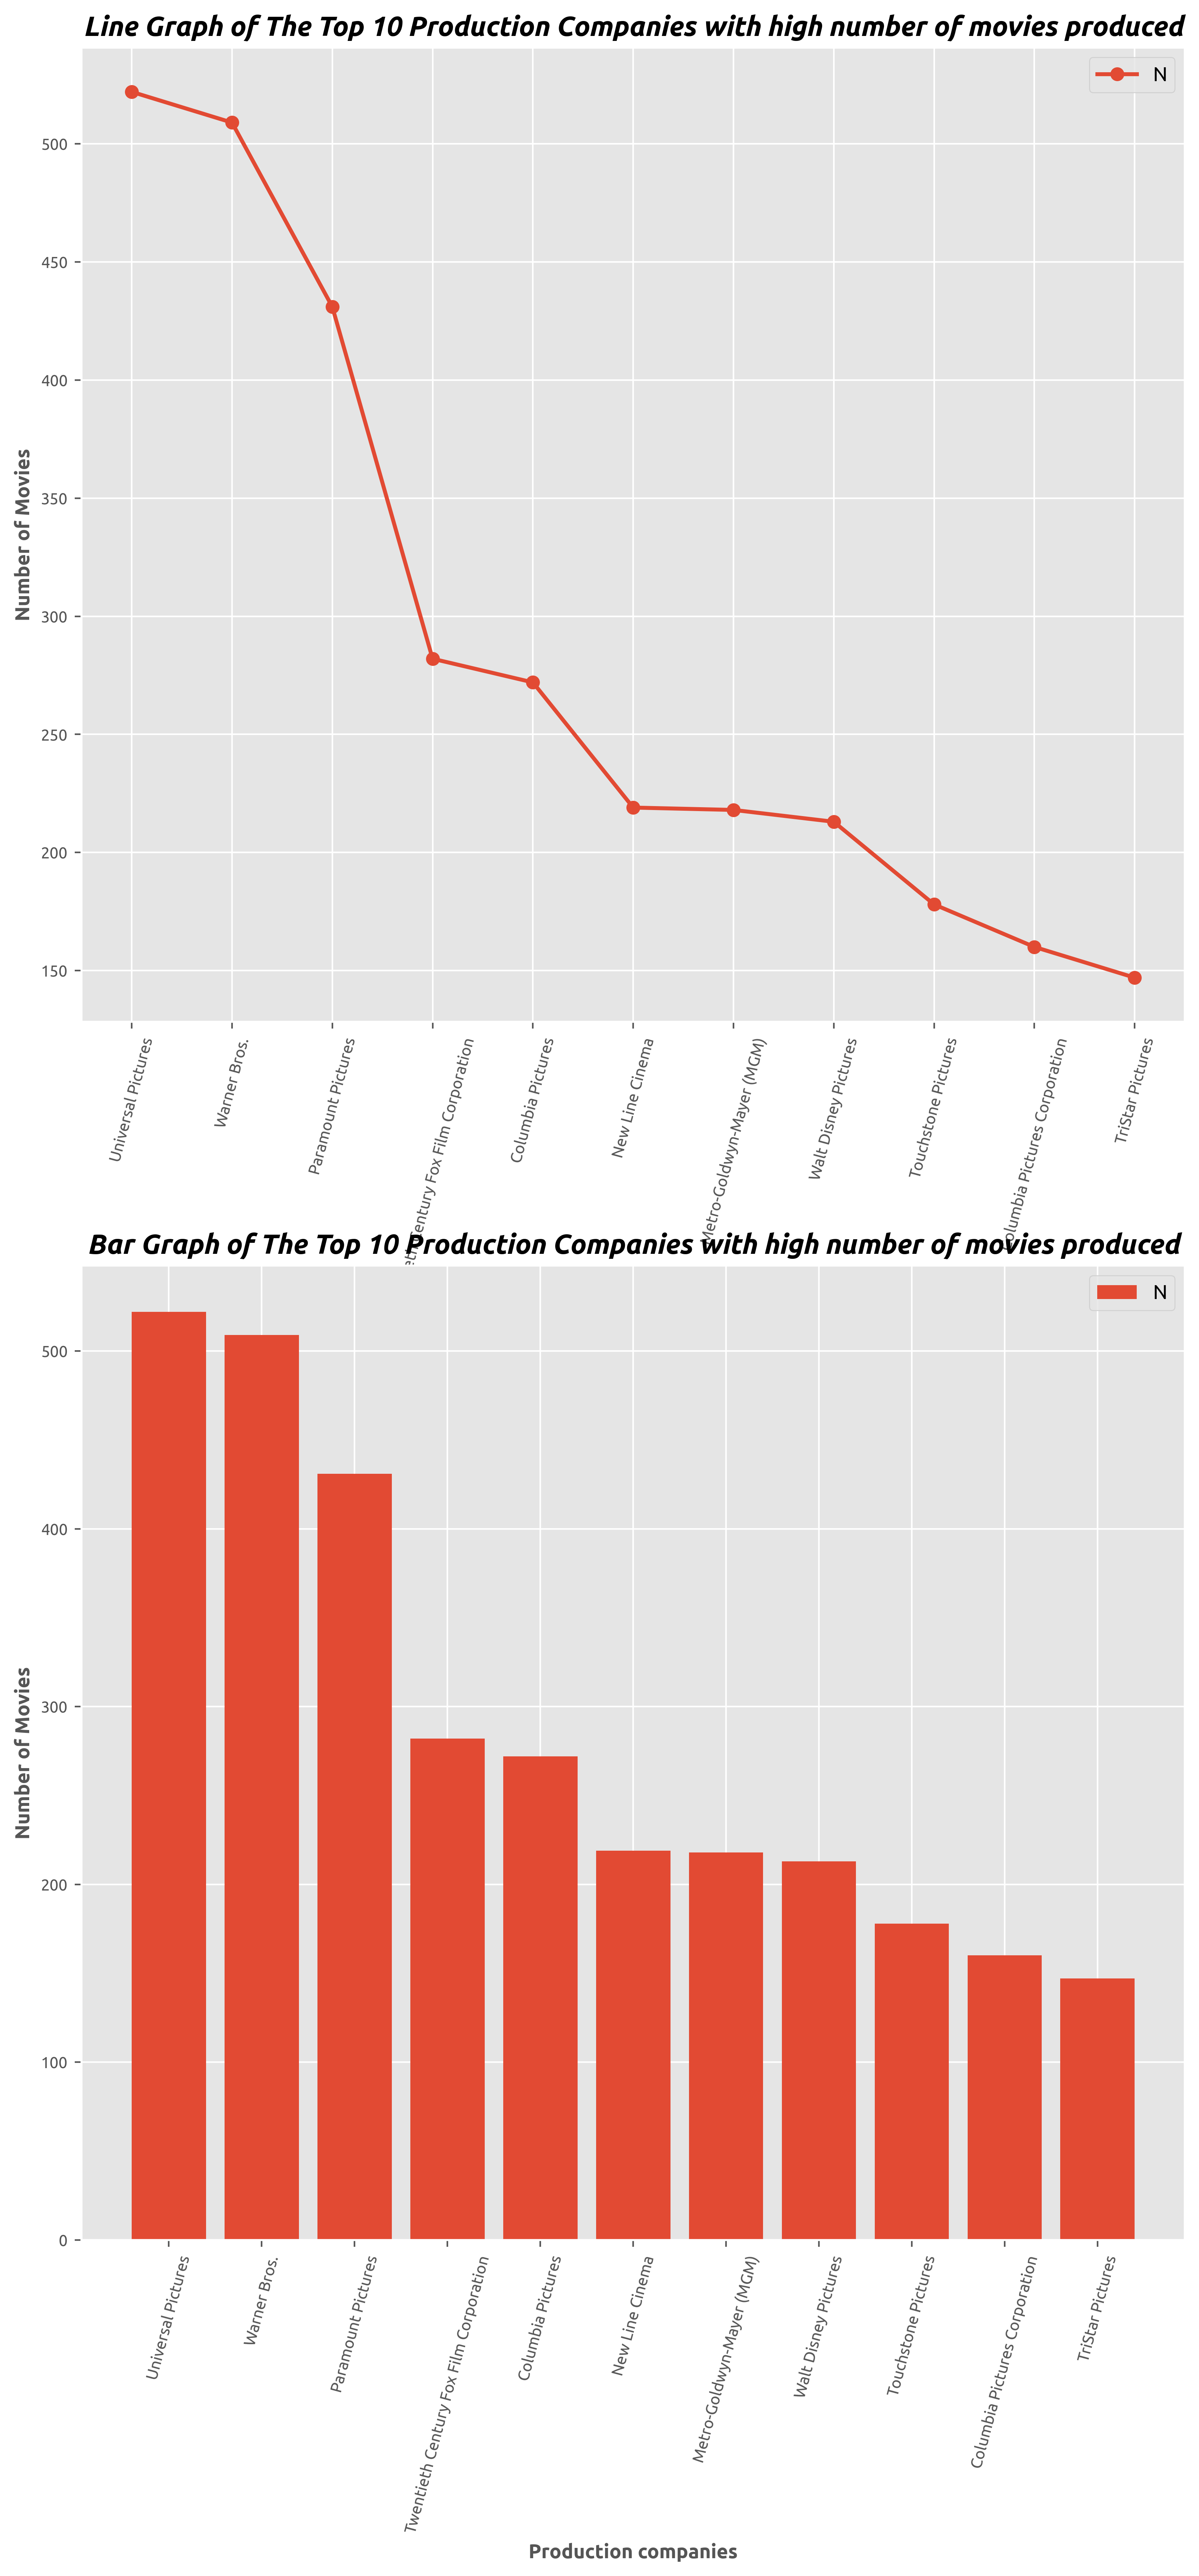

In [39]:
#Visualing the top 10 production companies with the highest number of movies over the years
plot_data(df = top_10, col = [], labels=['Production companies', 'Number of Movies'], title = 'The Top 10 Production Companies with high number of movies produced')

- Universal Pictures is the production company with the highest number of movies over the years followed by Warner Bros with Tristar Pictures having the least movies produced

<a id= 'eda9'></a>
### #9  How many production companies have produced 5 or less movies over the years?

<ul>
    <li><a href='#home'>Home</a></li>
</ul>


In [40]:
# production companies with 5 or less movies produced
_5less = df_splitted_comp.production_companies.value_counts()
_5less = _5less.where(_5less <= 5).dropna()

print('The Number of Companies with  5 or less movies produced are {}'.format(_5less.shape[0]))

The Number of Companies with  5 or less movies produced are 7187


<a id= 'conclusion'></a>
## Conclusions

<ul>
    <li><a href='#home'>Home</a></li>
</ul>

From Analysing the TMDb movies data, the following answers were discovered for the questions asked earlier.

### #1 Which genre is common amongst the most popular movies over the years?

> To get the answer for this question, a bar and a line graph was plotted (Fig 1.0) to determine the genre with the highest frequency among the popular movies. From the result, the most common genre was Drama and the least common is TV Movie.

<ul>
    <li><a href='#eda1.10'>Fig 1.0</a></li>
</ul>

### #2 Which genres are associated with high budgets?. Do they come with high revenue and profits?

>By using the averages of the budget, revenue and profit (all adjusted for inflation), all over the analysed years (From 1960 to 2015), The genres with the highest budgets are 
> 1. Adeventure 
> 2. Fantansy
> 3. Action 
> 4. Animation 
> 5. Family 
> 6. War  
> 7. Western Crime
> 8. Thriller 
> 9. History
> 10. Science Fiction

>All these genres also come with higher revenues and profits as depicted in the .bar and line charts

<ul>
    <li><a href='#eda2.10'>Fig 2.0</a></li>
</ul>

### #3 Did any genre record a loss over the years? And by how much?

>Yes, Foreign Movies recorded a loss of USD -506974.60
as shown from the plotted line and bar graph

<ul>
    <li><a href='#eda3.10'>Fig 3.0</a></li>
</ul>

### #4 The higher the average popularity of a genre, the higher the average profit?
>Using OLS regression, the R score is 0.714 approximately which means the independent variable popularity expalins 71.4 percent variation in the dependent variable profit. And the coefficient of popularity is 0.94 and has a positive sign showing a postive relationship between popularity and profit.

<ul>
    <li><a href='#eda4.10'>Table 1.0</a></li>
</ul>

### #5 What are the features of popular movies in terms of budget, revenue, and profit?


>The observation from the graph shows from year to year, when the budget increases, so does the revenue and profit but in the years from 1996 to 2015 depicts budgets decreasing but with high level of fluctuations whereas the revenue and profit are slightly stable with very low levels of fluctuations
<ul>
    <li><a href='#eda5.10'>Fig 4.0</a></li>
</ul>

### #6. What are the features of popular movies in terms of budget, revenue, and profit in the last five 
> The charts depict fluctuations in the budget, revenue and profit from 2010 to 2013.
From 2013 to 2015, there was a sharp fall in the budget with an insignificant level of fluctuationto 2014 and then begun a less steep fall from 2014 to 2015, however, within these years, the revenue and profit fell sharply to 2014, and then increased from 2014 to 2015.
<ul>
    <li><a href='#eda6.10'>Fig 5.0</a></li>
</ul>

### #7  Which production companies are among the top 10 movie producers of popular movies?

> 1. Warner Bros 
> 2. Universal Pictures 
> 3. Paramount Pictures 
> 4. Twentieth Century Fox Film Corporation
> 5. Columbia Pictures
> 6. Walt Disney Pictures
> 7. New Line Cinema
> 8. Relativity Media
> 9. Metro-Goldwyn-Mayer (MGM)
> 10. Columbia Pictures Corporation
> 11. Touchstone Pictures 
>
in their respective order

<ul>
    <li><a href='#eda7.10'>Fig 6.0</a></li>
</ul>

### #8 Which production companies are the overall top 10 movie producers and how many movies have they produced over the years?

> 1. Universal Pictures
> 2. Warner Bros. 
> 3. Paramount Pictures
> 4. Twentieth Century Fox Film Corporation
> 5. Columbia Pictures
> 6. New Line Cinema
> 7. Metro-Goldwyn-Mayer (MGM)
> 8. Walt Disney Pictures
> 9. Touchstone Pictures
> 10 .Columbia Pictures Corporation
> 11. TriStar Pictures
>
in their respective order

<ul>
    <li><a href='#eda8.10'>Fig 7.0</a></li>
</ul>

### #9 How many production companies have produced 5 or less movies over the years?

> 7187 production companies have produced five movies or less from1960 to 2015

## Limitations
1. Even though some of the features of the data were self explanatory, the runtime feature does not have clear explanation on the source site

2. The unit of some features were hard to find or not available on the source site for example, the runtime.

3. From 1960 to 2015, new and advanced technology has led to the introduction of streaming sites and others. Thus, a feature to describe how the rating was gathered and how the popularity was also determine would have helped made analysis on this features more clearer


# References

1. TMDb data- source: https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata

2. Matplotlib plot bar chart -  https://pythonguides.com/matplotlib-plot-bar-chart/

3. Matplotlib: beautiful plots with style - http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
